# Drift Detection in Multiclass Imbalanced Datastreams

In [ ]:
from river import tree, metrics
from river.datasets import synth
from river.drift import ADWIN, KSWIN, PageHinkley
from river.drift.binary import DDM

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
import seaborn as sns
import math
import itertools
import time
from scipy.stats import friedmanchisquare, pearsonr
import scikit_posthocs as sp

from sklearn.decomposition import IncrementalPCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score as AUC
from sklearn.model_selection import StratifiedKFold

import torch
import torch.nn as nn
import torch.nn.functional as F

## Metric Tracker

In [ ]:
class MetricsTracker:

    def __init__(self, max_delay=2000, min_delay=100):
        self.en_accuracy = metrics.Accuracy()
        self.g_mean = metrics.GeometricMean()
        self.kappa = metrics.CohenKappa()
        self.current_step = 0
        self.max_delay = max_delay
        self.min_delay = min_delay

        self.injected_drifts = []
        self.detected_drift_ids = set()
        self.false_alarms = 0
        self.all_delays = []
        self.acc_history = []
        self.gmean_history = []
        self.processing_times = []
        self.fa_steps = []
        self.last_drift_end = 0

    def update(
        self,
        y_true,
        y_pred,
        drift_detected=False,
        gt_drifts=None,
        step_time=None,
    ):
        if step_time is not None:
            self.processing_times.append(step_time)

        if y_pred is not None:
            self.en_accuracy.update(y_true, y_pred)
            self.g_mean.update(y_true, y_pred)
            self.kappa.update(y_true, y_pred)

        if gt_drifts is not None and len(self.injected_drifts) == 0:
            self.injected_drifts = gt_drifts

        self.acc_history.append(self.en_accuracy.get())
        self.gmean_history.append(self.g_mean.get())

        if drift_detected:
            closest_idx = None
            closest_dist = float("inf")

            for i, drift_step in enumerate(self.injected_drifts):
                if i in self.detected_drift_ids:
                    continue
                
                dist = self.current_step - drift_step

                # Check if the detection falls within the allowed window
                # From -min_delay steps before, up to +max_delay steps after
                if -self.min_delay <= dist <= self.max_delay:
                    if abs(dist) < abs(closest_dist):
                        closest_dist = dist
                        closest_idx = i

            if closest_idx is not None:
                self.detected_drift_ids.add(closest_idx)

                # If the alert was early (negative distance), we clamp the delay to 1
                # so it doesn't artificially lower mean MTD delay calculation.
                actual_delay = max(1, closest_dist)
                self.all_delays.append(actual_delay)
            else:
                # TRUE FALSE ALARM (Outside both pre-drift and post-drift windows)
                self.false_alarms += 1
                self.fa_steps.append(self.current_step)

        self.current_step += 1

    def get_metrics(self):
        n_injected = len(self.injected_drifts)
        tp = len(self.detected_drift_ids)
        fp = self.false_alarms
        missed = n_injected - tp

        mtd = np.mean(self.all_delays) if self.all_delays else 0.0

        steps_spent_in_drift = tp * mtd
        n_stable = self.current_step - steps_spent_in_drift

        if fp > 0:
            mtfa = n_stable / fp
        else:
            mtfa = n_stable

        mdr = missed / n_injected if n_injected > 0 else 0.0

        if mtd > 0:
            mtr = (mtfa / mtd) * (1.0 - mdr)
        else:
            mtr = 0.0

        recall = tp / n_injected if n_injected > 0 else 0.0
        total_alerts = tp + fp
        precision = tp / total_alerts if total_alerts > 0 else 0.0
        far = fp / total_alerts if total_alerts > 0 else 0.0
        hdd = (
            2 * (precision * recall) / (precision + recall)
            if (precision + recall) > 0
            else 0.0
        )

        avg_latency = np.mean(self.processing_times) * 1000 if self.processing_times else 0

        return {
            "Prediction Accuracy": round(self.en_accuracy.get() * 100, 2),
            "Prediction G-Mean": round(self.g_mean.get() * 100, 2),
            "Kappa": round(self.kappa.get(), 4),
            "MTD (Delay)": round(mtd, 2),
            "MTFA": round(mtfa, 2),
            "MTR": round(mtr, 4),
            "Recall": round(recall * 100, 2),
            "Precision": round(precision * 100, 2),
            "FAR": round(far * 100, 2),
            "HDD": round(hdd * 100, 2),
            "Latency_ms": round(avg_latency, 4),
        }


## Drift Detectors

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self, x_dim, p_dim, hidden_dim=16, latent_dim=8):
        super().__init__()

        self.x_dim = x_dim
        self.p_dim = p_dim
        self.input_dim = x_dim + p_dim

        # Shared encoder
        self.encoder = nn.Sequential(
            nn.Linear(self.input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim),
            nn.ReLU()
        )

        # Feature decoder
        self.decoder_x = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, x_dim)
        )

        # Probability decoder
        self.decoder_p = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, p_dim),
            #nn.Softmax(dim=1) 
            nn.LogSoftmax(dim=1)
        )

    def forward(self, x, p):
        z = torch.cat([x, p], dim=1)
        h = self.encoder(z)

        x_hat = self.decoder_x(h)
        p_hat = self.decoder_p(h)

        return x_hat, p_hat
    
class DHAEv5:  # WCE+MSE
    def __init__(
        self,
        n_features,
        n_classes,
        hidden_dim=16,
        latent_dim=8,
        lr=1e-3,
        delta=0.002,          
        warmup_steps=1000,    
        adaptation_steps=500  
    ):
        self.n_classes = n_classes
        self.model = Autoencoder(n_features, n_classes, hidden_dim, latent_dim)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)

        self.adwin = ADWIN(delta=delta)
        self.step = 0
        
        # for adaptation
        self.is_adapting = False
        self.steps_since_drift = 0
        self.min_adaptation_steps = adaptation_steps 
        self.warmup_steps = warmup_steps

        # for analysis and visualisation
        self.loss_history = []
        self.loss_history_x = [] 
        self.loss_history_p = []
        self.adwin_width_history = []
        self.weights_history=[]

    def _to_tensors(self, x, probas):
        if not probas:
            probas = {c: 1.0 / self.n_classes for c in range(self.n_classes)}
        p_list = [probas.get(c, 1e-3) for c in range(self.n_classes)]
        p_tensor = torch.FloatTensor(p_list).unsqueeze(0)
        x_tensor = torch.FloatTensor(list(x.values())).unsqueeze(0)
        return x_tensor, p_tensor
     
    def _compute_loss(self, x, x_hat, p, p_hat):
        # Feature Loss (MSE)
        loss_x = F.mse_loss(x_hat, x)

        # Weighted Cross-Entropy 
        weights = 1.0 / torch.sqrt(p + 1e-3)
        weights = weights / weights.mean()
        ce_elementwise = -(p * p_hat) 
        loss_p = (weights * ce_elementwise).sum(dim=1).mean()

        # Total Loss 
        total_loss =loss_x + loss_p
        return total_loss, loss_p, loss_x, weights

    def update(self, x, probas, **kwargs):
        self.step += 1
        x_tensor, p_tensor = self._to_tensors(x, probas)
        self.model.eval()
        with torch.no_grad():
            x_hat, p_hat = self.model(x_tensor, p_tensor)
            loss_val, lp, lx, weights = self._compute_loss(x_tensor, x_hat, p_tensor, p_hat) 
        
        # for plots
        loss_val = loss_val.item()
        loss_p_val = lp.item()
        loss_x_val = lx.item()
        w_vals = weights.detach().cpu().numpy().tolist() 
        self.weights_history.append(w_vals)
        self.loss_history.append(loss_val)
        self.loss_history_x.append(loss_x_val)
        self.loss_history_p.append(loss_p_val)
        self.adwin_width_history.append(self.adwin.width)

        # WARMUP
        if self.step <= self.warmup_steps:
            self._train_step(x_tensor, p_tensor)
            return False

        # ADAPTATION
        if self.is_adapting:
            self.steps_since_drift += 1
            self._train_step(x_tensor, p_tensor)
            if self.steps_since_drift >= self.min_adaptation_steps:
                print(f"--- Resume monitoring at step {self.step} ---")
                self.is_adapting = False
            return False

        # MONITORING
        self.adwin.update(loss_val)
        if self.adwin.drift_detected:
            print(f"!!! Drift at {self.step} (score= {loss_val:.4f}). Adapting")
            self.is_adapting = True
            self.steps_since_drift = 0
            return True

        return False

    def _train_step(self, x, p):
        self.model.train()
        self.optimizer.zero_grad()
        x_hat, p_hat = self.model(x, p)
        loss,_,_ ,_= self._compute_loss(x, x_hat, p, p_hat)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
        self.optimizer.step()


In [ ]:
class D3:
    """Implementation of the Discriminative Drift Detector (D3) based on Gözüaçik et al."""
    def __init__(self, w=1000, rho=0.1, threshold=0.75):
        self.w = w                  # Old window
        self.rho = rho              # New window
        self.threshold = threshold  # AUC threshold
        
        self.size = int(w * (1 + rho))
        self.dim = None
        self.buffer = []
        self.step = 0

    def update(self, x, **kwargs):
        self.step += 1
        features = np.fromiter(x.values(), dtype=float) if isinstance(x, dict) else np.array(x)
        
        if self.dim is None:
            self.dim = len(features)
            
        self.buffer.append(features)

        if len(self.buffer) < self.size:
            return False

        if self._drift_check():
            new_data_start = self.w
            self.buffer = self.buffer[new_data_start:]
            return True
        else:
            shift = int(self.w * self.rho)
            self.buffer = self.buffer[shift:]
            return False

    def _drift_check(self):
        data = np.array(self.buffer)

        S = data[:self.w]
        T = data[self.w:]
        
        labels = np.zeros(len(data))
        labels[:self.w] = 1 
        
        clf = LogisticRegression(solver='liblinear', max_iter=1000)
        predictions = np.zeros(labels.shape)
        
        skf = StratifiedKFold(n_splits=2, shuffle=True)
        try:
            for train_idx, test_idx in skf.split(data, labels):
                X_train, X_test = data[train_idx], data[test_idx]
                y_train, y_test = labels[train_idx], labels[test_idx]
                
                clf.fit(X_train, y_train)
                probs = clf.predict_proba(X_test)[:, 1]
                predictions[test_idx] = probs
                
            auc_score = AUC(labels, predictions)
            return auc_score > self.threshold
        except Exception as e:
            print(e)
            return False

class ADWIN_AE: 
    def __init__(self, n_features, hidden_dim=16, latent_dim=8, lr=1e-3, delta=0.002):
        # Autoencoder
        self.model = nn.Sequential(
            nn.Linear(n_features, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim),
            nn.ReLU(),
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, n_features)
        )
        
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)
        
        # 2. Detection Module
        self.adwin = ADWIN(delta=delta)
        
        self.step = 0
        self.warmup_steps = 1000
      
        self.is_adapting = False
        self.adaptation_counter = 0
        self.min_adaptation_steps = 500

    def _train_step(self, x_tensor):
        self.model.train()
        self.optimizer.zero_grad()
        x_hat = self.model(x_tensor)
        loss = F.mse_loss(x_hat, x_tensor)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
        self.optimizer.step()
        return loss.item()

    def update(self, x, **kwargs):
        self.step += 1
        
        x_vals = list(x.values()) if isinstance(x, dict) else x
        x_tensor = torch.FloatTensor(x_vals).unsqueeze(0)
        
        self.model.eval()
        with torch.no_grad():
            x_hat = self.model(x_tensor)
            current_loss = current_loss = torch.norm(x_tensor - x_hat,p=2,dim=1).item()

        # WARMUP
        if self.step <= self.warmup_steps:
            self._train_step(x_tensor)
            return False

        # ADAPTATION
        if self.is_adapting:
            self._train_step(x_tensor)
            self.adaptation_counter += 1
            if self.adaptation_counter >= self.min_adaptation_steps:
                self.is_adapting = False
            return False

        # MONITORING
        self.adwin.update(current_loss)
        
        if self.adwin.drift_detected:
            #print("drift detected at step", self.step)
            self.is_adapting = True
            self.adaptation_counter = 0
            return True # Drift Detected!

        return False

class ADWINEntropy:
    def __init__(
        self,
        delta=0.005,
        n_classes=8,
        cooldown=200
    ):
        self.adwin = ADWIN(delta=delta)
        self.n_classes = n_classes

        self.cooldown = cooldown
        self.cooldown_counter = 0

    def _compute_entropy(self, probas):
        p = np.array([probas.get(c, 1e-8) for c in range(self.n_classes)], dtype=float)
        if p.sum() == 0:
            p = np.ones(self.n_classes) / self.n_classes
        else:
            p = p / p.sum()
        p = np.clip(p, 1e-8, 1.0) 
        entropy = -np.sum(p * np.log(p)) # Shannon Entropy
        entropy /= np.log(self.n_classes) # Normalization

        return entropy

    def update(self, probas,**kwargs):
        if self.cooldown_counter > 0:
            self.cooldown_counter -= 1
            return False
        entropy = self._compute_entropy(probas)
        self.adwin.update(entropy)
        if self.adwin.drift_detected:
            self.cooldown_counter = self.cooldown
            return True

        return False

class ADWINError:
    def __init__(self, delta=0.002):
        self.adwin = ADWIN(delta=delta)
        self.cooldown = 0
    def update(self, y_true, y_pred, **kwargs):
        if self.cooldown > 0:
            self.cooldown -= 1
            return False
        if y_true is None or y_pred is None:
            return False
        error = 1.0 if y_true != y_pred else 0.0
        self.adwin.update(error)
        if self.adwin.drift_detected:
            self.cooldown = 250 
            return True 
        return False

class PHWrapper:
    def __init__(self, delta=0.005, threshold=50, min_instances=30):
        self.ph = PageHinkley(delta=delta, threshold=threshold, min_instances=min_instances)
        self.cooldown = 0

    def update(self, y_true, y_pred, **kwargs):
        if self.cooldown > 0:
            self.cooldown -= 1
            return False
            
        if y_true is None or y_pred is None:
            return False
            
        error = 1.0 if y_true != y_pred else 0.0
        # В River метод называется update
        self.ph.update(error)
        
        if self.ph.drift_detected:
            self.cooldown = 250 
            return True 
        return False

class DDMWrapper:
    def __init__(self):
        self.ddm = DDM()

    def update(self, y_true=None, y_pred=None,**kwargs):
        if y_true is None or y_pred is None:
            return False

        error = 0 if y_pred == y_true else 1

        self.ddm.update(error)

        return self.ddm.drift_detected
      
class PCAKSWIN:
    def __init__(self, n_components=2, alpha=0.005, window_size=100, stat_size=30):
       
        self.pca = IncrementalPCA(n_components=n_components)
        # KSWIN monitors 1st component
        self.detector = KSWIN(alpha=alpha, window_size=window_size, stat_size=stat_size)
        
        self.n_components = n_components
        self.buffer = []
        self.buffer_size = 50  
        self.is_fitted = False
        self.drift_detected = False

    def update(self, x, **kwargs):
        self.drift_detected = False
        x = np.array(list(x.values()) if isinstance(x, dict) else x).reshape(1, -1)
        
        self.buffer.append(x.flatten())
        
        if len(self.buffer) >= self.buffer_size:
            # Partial fit PCA
            self.pca.partial_fit(self.buffer)
            self.buffer = []
            self.is_fitted = True

        if self.is_fitted:
            x_transformed = self.pca.transform(x)
            # take 1st component
            first_pc = x_transformed[0, 0]
            self.detector.update(first_pc)
            self.drift_detected = self.detector.drift_detected
            
        return self.drift_detected

class NoChangeDetector:
    def __init__(self, interval=60):
        """No-change baseline detector that triggers a drift signal every N samples"""
        self.interval = interval
        self.sample_counter = 0
        self.drift_detected = False

    def update(self, y_true=None, y_pred=None, **kwargs):
        # Maintain identical interface compatibility
        if y_true is None or y_pred is None:
            return False

        # Increment step counter for every incoming instance
        self.sample_counter += 1
        
        # Check if the periodic window is reached
        if self.sample_counter >= self.interval:
            self.drift_detected = True
            self.sample_counter = 0  # Reset counter immediately after firing
        else:
            self.drift_detected = False

        return self.drift_detected


## RBF 

In [7]:
class RBFDriftStream:
    def __init__(self, 
                 n_classes=8, 
                 n_features=10, 
                 drift_points=[], 
                 drift_width=1, 
                 imbalance_configs=None, 
                 seed=42
        ):
        self.n_classes = n_classes
        self.n_features = n_features
        self.drift_points = drift_points
        self.drift_width = drift_width
        self.seed = seed
        self.step = 0
        self.rng = np.random.RandomState(seed)

        num_stages = len(drift_points) + 1
        
        # Handling imbalance
        self.class_counts = np.zeros(n_classes)
        if imbalance_configs is None:
            self.imbalance_configs = [{c: 1/n_classes for c in range(n_classes)}] * num_stages
        else:
            self.imbalance_configs = []
            for config in imbalance_configs:
                total = sum(config.values())
                normalized = {c: config.get(c, 0) / (total if total > 0 else 1) for c in range(n_classes)}
                self.imbalance_configs.append(normalized)
            while len(self.imbalance_configs) < num_stages:
                self.imbalance_configs.append(self.imbalance_configs[-1])

        self.concept_seeds = [self.seed + i for i in range(num_stages)]
        
        self.stages = [
            iter(synth.RandomRBF(seed_model=s, n_classes=n_classes, n_features=n_features))
            for s in self.concept_seeds
        ]

    def __iter__(self):
        return self
    
    def __next__(self):
        while True:
            stage_idx = 0
            for i, p in enumerate(self.drift_points):
                if self.step >= p:
                    stage_idx = i + 1
            stage_idx = min(stage_idx, len(self.stages) - 1)
            
            # Sudden or Gradual Drift
            active_gen_idx = stage_idx
            if self.drift_width > 1:
                if stage_idx > 0:
                    drift_start = self.drift_points[stage_idx-1]
                    if drift_start <= self.step < drift_start + self.drift_width:
                        prob_new = (self.step - drift_start) / self.drift_width
                        if self.rng.rand() > prob_new:
                            active_gen_idx = stage_idx - 1
                        
            # Feature generation
            x, y = next(self.stages[active_gen_idx])
            
            # Dynamic Compensation
            target_dist = self.imbalance_configs[stage_idx]
            target_prob = target_dist.get(y, 0)
            current_share = self.class_counts[y] / (sum(self.class_counts) + 1e-9)
            
            if current_share < target_prob:
                keep_prob = 1.0
            else:
                keep_prob = 0.01 
            
            if self.rng.rand() < keep_prob:
                self.class_counts[y] += 1
                self.step += 1
                return x, y

    def take(self, n):
        return itertools.islice(self, n)


In [8]:
class HyperplaneDriftStream:

    def __init__(
        self,
        n_classes=8,
        n_features=10,
        drift_points=[],
        drift_width=1,
        imbalance_configs=None,
        seed=42
    ):

        self.n_classes = n_classes
        self.n_features = n_features
        self.drift_points = drift_points
        self.drift_width = drift_width
        self.seed = seed

        self.step = 0
        self.rng = np.random.RandomState(seed)

        num_stages = len(drift_points) + 1

        self.weights = [] # hyperplane 

        for i in range(num_stages):
            W = self.rng.rand(n_classes, n_features)
            W = W / np.linalg.norm(W, axis=1, keepdims=True) # normalize
            self.weights.append(W)

        self.class_counts = np.zeros(n_classes) # imbalance

        if imbalance_configs is None:
            self.imbalance_configs = [{c: 1 / n_classes for c in range(n_classes)} for _ in range(num_stages)]
        else:
            self.imbalance_configs = []
            for config in imbalance_configs:
                total = sum(config.values())
                normalized = {c: config.get(c, 0) / total for c in range(n_classes)}
                self.imbalance_configs.append(normalized)
            while len(self.imbalance_configs) < num_stages:
                self.imbalance_configs.append(self.imbalance_configs[-1])

    def __iter__(self):
        return self

    def _current_stage(self):
        stage_idx = 0
        for i, p in enumerate(self.drift_points):
            if self.step >= p:
                stage_idx = i + 1
        return min(stage_idx, len(self.weights) - 1)

    def __next__(self):

        while True:

            stage_idx = self._current_stage()

            active_stage = stage_idx

            # gradual drift
            if self.drift_width > 1 and stage_idx > 0:
                drift_start = self.drift_points[stage_idx - 1]
                if drift_start <= self.step < drift_start + self.drift_width:
                    prob_new = (self.step - drift_start) / self.drift_width
                    if self.rng.rand() > prob_new:
                        active_stage = stage_idx - 1

            x = self.rng.rand(self.n_features) # generate features

            logits = self.weights[active_stage] @ x # matrix multiplication, shape (n_classes,)

            y = np.argmax(logits) # class with highest logit

            target_dist = self.imbalance_configs[stage_idx] # imbalance handling
            target_prob = target_dist.get(y, 0)
            total = np.sum(self.class_counts) + 1e-9
            current_share = self.class_counts[y] / total
            keep_prob = (1.0 if current_share < target_prob else 0.01)

            if self.rng.rand() < keep_prob:
                self.class_counts[y] += 1
                self.step += 1
                x_dict = {f"f{i}": float(v) for i, v in enumerate(x)}
                return x_dict, y

    def take(self, n):
        return itertools.islice(self, n)

## Visualisation

In [9]:
def plot_adwin_behavior(dhae_instance, gt_drifts, detected_drifts):
    plt.figure(figsize=(15, 6))
    plt.plot(dhae_instance.adwin_width_history, color='blue', linewidth=2, label='ADWIN Window Size')

    # 3. Линии РЕАЛЬНОГО дрейфа (Красный пунктир)
    for i, drift in enumerate(gt_drifts):
        plt.axvline(x=drift, color='red', linestyle='--', linewidth=2, label='Ground Truth Drift' if i == 0 else "")

    # 4. Линии ОБНАРУЖЕННОГО дрейфа (Зеленая сплошная)
    if detected_drifts is not None:
        for i, d in enumerate(detected_drifts):
            plt.axvline(x=d, color='green', linestyle='-', linewidth=2, alpha=0.8,label='Detected Drift' if i == 0 else "")

    plt.title('ADWIN Window Size', fontsize=14, fontweight='bold')
    plt.xlabel('Steps', fontsize=12)
    plt.ylabel('ADWIN Window Size', fontsize=12)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_loss_breakdown(dhae_instance, gt_drifts, detected_drifts=None, window=500):
    plt.figure(figsize=(15, 6))
    
    # 1. Сглаживание через Pandas
    loss_x_smooth = pd.Series(dhae_instance.loss_history_x).rolling(window=window).mean()
    loss_p_smooth = pd.Series(dhae_instance.loss_history_p).rolling(window=window).mean()
    loss_smooth = pd.Series(dhae_instance.loss_history).rolling(window=window).mean()

    steps = np.arange(len(loss_x_smooth))

    # Рисуем сглаженные линии
    plt.plot(steps, loss_smooth, label=f'Total Loss (X+P) [SMA {window}]',color='gray', linewidth=1.5)
    plt.plot(steps, loss_p_smooth, label=f'Loss P [SMA {window}]', color='#e67e22', linewidth=1.5)
    plt.plot(steps, loss_x_smooth, label=f'Loss X [SMA {window}]',color='#3498db', linewidth=1.5)
    #plt.plot(steps, loss_smooth, label=f'Total Loss (X+P) [SMA {window}]',color='gray', linewidth=1.5)

    # 3. Линии РЕАЛЬНОГО дрейфа (Красный пунктир)
    for i, drift in enumerate(gt_drifts):
        plt.axvline(x=drift, color='red', linestyle='--', linewidth=2, label='Ground Truth Drift' if i == 0 else "")

    # 4. Линии ОБНАРУЖЕННОГО дрейфа (Зеленая сплошная)
    if detected_drifts is not None:
        for i, d in enumerate(detected_drifts):
            plt.axvline(x=d, color='green', linestyle='-', linewidth=2, alpha=0.8,label='Detected Drift' if i == 0 else "")

    plt.title(f'Reconstruction Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Steps', fontsize=12)
    plt.ylabel('Loss Value', fontsize=12)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [10]:
def plot_detection_results(results_dict, ground_truth_drifts, X_df=None, feature_idx=0, window=500):

    n_detectors = len(results_dict)
    cols = 2
    rows = math.ceil(n_detectors / cols)
    
    plt.figure(figsize=(20, 5 * rows))
    concept_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

    for i, (name, data) in enumerate(results_dict.items()):
        ax = plt.subplot(rows, cols, i + 1)
        
        # Take first run
        tracker = data["all_trackers"][0]
        drifts = data["all_drifts"][0]
        
        # Concepts
        stream_len = len(tracker.acc_history)
        boundaries = [0] + (ground_truth_drifts if ground_truth_drifts else []) + [stream_len]
        
        for j in range(len(boundaries) - 1):
            ax.axvspan(boundaries[j], boundaries[j+1], 
                       color=concept_colors[j % len(concept_colors)], alpha=0.2)

        # Metrics
        ax.plot(tracker.acc_history, color='orange', label='Accuracy', alpha=0.8)
        ax.plot(tracker.gmean_history, color='green', label='G-Mean', alpha=0.8)

        # Feature trend
        if X_df is not None:
            trend = X_df.iloc[:, feature_idx].rolling(window).mean()
            norm_trend = (trend - trend.min()) / (trend.max() - trend.min() + 1e-9)
            ax.plot(norm_trend, color='gray', alpha=0.3, linestyle=':', label='Feature Trend')

        # Drift detection lines
        for d in drifts:
            ax.axvline(x=d, color='red', linestyle='--', linewidth=1.5)

        ax.set_title(f"Detector: {name}", fontsize=14, fontweight='bold')
        ax.set_ylim(0, 1.1)
        ax.legend(loc='lower left', fontsize=9, ncol=3)

    plt.tight_layout()
    plt.show()


In [11]:
def plot_metrics(results):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Accuracy 
    for name, result in results.items():
        tracker = result["tracker"]
        axes[0].plot(tracker.acc_history, label=name)

    axes[0].set_title("Accuracy")
    axes[0].set_xlabel("Step")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].grid(True)

    # G-Mean
    for name, result in results.items():
        tracker = result["tracker"]
        axes[1].plot(tracker.gmean_history, label=name)

    axes[1].set_title("G-Mean")
    axes[1].set_xlabel("Step")
    axes[1].set_ylabel("G-Mean")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

In [12]:
def print_summary(summary, title="Results"):
    print("\n" + "="*40)
    print(title)
    print("="*40)

    for metric, stats in summary.items():
        print(f"{metric:20}: {stats['mean']:.4f} ± {stats['std']:.4f}")

In [13]:
def stream_to_df(stream, n_samples):
    data = []
    for i, (x, y) in enumerate(stream.take(n_samples)):
        row = {**x, 'label': y}
        data.append(row)
    return pd.DataFrame(data)

In [ ]:
def calculate_lrid_norm(class_counts):
    class_counts = np.array(class_counts, dtype=float)
    N = np.sum(class_counts)
    C = len(class_counts)
    lrid = -2 * np.sum(class_counts/N * np.log(N / (C * class_counts) + 1e-12))
    
    return lrid

def calculate_entropy_balance(class_counts):
    counts = np.array(class_counts, dtype=float)
    N = np.sum(counts)
    C = len(counts)
    p_hat = counts / N # Calculate class proportions (probabilities)
    entropy = -np.sum(p_hat * np.log(p_hat + 1e-12)) # Calculate Shannon Entropy
    balance_score = entropy / np.log(C) # Normalize by max possible entropy
    return balance_score

def calculate_simba(X, y):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y)

    N = len(y)
    classes, counts = np.unique(y, return_counts=True)
    C = len(classes)
    eps = 1e-12

    distribution_term = 0.0
    for n_c in counts:
        p_c = n_c / N
        distribution_term += (p_c * np.log(N / (C * n_c + eps)))
    distribution_term *= -2

    y_onehot = pd.get_dummies(y).values.astype(float)
    n_features = X.shape[1]
    total_corr = 0.0
    for i in range(n_features):
        feature = X[:, i]
        if np.std(feature) == 0: # skip constant features
            continue
        for c in range(C):
            class_vector = y_onehot[:, c]
            corr, _ = pearsonr(feature, class_vector)
            if not np.isnan(corr):
                total_corr += abs(corr)

    r_bar = total_corr / (C * n_features + eps)
    simba = distribution_term / (r_bar + eps)

    return simba

def compute_window_imbalance_metrics(X,y,window_size=1000,step_size=100):
    """Compute imbalance metrics over sliding windows."""

    results = []
    n_samples = len(y)

    for start in range(0, n_samples - window_size + 1, step_size):
        end = start + window_size

        X_window = X[start:end]
        y_window = y[start:end]

        # class counts
        _, counts = np.unique(y_window, return_counts=True)

        # metrics
        entropy_score = calculate_entropy_balance(counts)
        lrid_score = calculate_lrid_norm(counts)
        simba_score = calculate_simba(X_window, y_window)

        results.append({
            "start": start,
            "end": end,
            "center": start + window_size // 2,
            "entropy": entropy_score,
            "lrid": lrid_score,
            "simba": simba_score
        })
    return pd.DataFrame(results)


def plot_imbalance_metrics(metrics_df,drift_points=None):
    """Plot imbalance metrics over time."""
    plt.figure(figsize=(14, 8))
    # Entropy
    plt.plot(metrics_df["center"],metrics_df["entropy"],label="C1",linewidth=2)
    # LRID
    plt.plot(metrics_df["center"],metrics_df["lrid"],label="LRID",linewidth=2)
    # SIMBA
    plt.plot(metrics_df["center"],metrics_df["simba"],label="SIMBA",linewidth=2)
    # Drift points
    if drift_points is not None:
        for d in drift_points:
            plt.axvline(d,linestyle="--",alpha=0.6)

    plt.xlabel("Stream Position")
    plt.ylabel("Metric Value")
    plt.title("Imbalance Metrics Over Time")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()



## Experiments

In [15]:
def run_experiment(
    X_dict,
    y_list,
    ground_truth_drifts,
    classifier_factory,
    detector_factory=None,
    reset_on_drift=False
):
    tracker = MetricsTracker()
    drifts = []

    classifier = classifier_factory()
    detector = detector_factory() if detector_factory else None

    for i, (x, y_true) in enumerate(zip(X_dict, y_list)):
        step_start = time.perf_counter() 

        # predict
        y_pred = classifier.predict_one(x)
        probas = classifier.predict_proba_one(x)

        # drift detection
        is_drift = False

        if detector is not None:
            is_drift = detector.update(
                y_true=y_true,
                y_pred=y_pred,
                probas=probas,
                x=x
            )
            if is_drift:
                drifts.append(i)
                if reset_on_drift:
                    classifier = classifier_factory()
        
        execution_time = time.perf_counter() - step_start

        # metrics
        tracker.update(
            y_true=y_true,
            y_pred=y_pred,
            drift_detected=is_drift,
            gt_drifts=ground_truth_drifts,
            step_time=execution_time
        )

        # learn
        classifier.learn_one(x, y_true)

    return drifts, tracker

In [16]:
def run_multiple_experiments(
    stream_type, 
    classifier_factory, 
    detector_factory=None,
    n_classes=8,
    n_features=30,
    drift_width=1,
    n_samples=10000,
    ground_truth_drifts=None,
    imbalance_configs=None,
    reset_on_drift=False, 
    n_runs=5
):
    
    all_metrics = []
    all_drifts = []   
    all_trackers = []

    for seed in range(n_runs):
        np.random.seed(seed)
        torch.manual_seed(seed)

        if stream_type == 'insects_gradual':
            path="data/INSECTS gradual_imbalanced.csv"
            ground_truth_drifts=[58159]
            imbalance_configs={12: 0.30, 3: 0.22, 2: 0.21, 11: 0.18, 4: 0.06, 5: 0.03}
            df = pd.read_csv(path, header=None)
            X_dict = df.iloc[:, :-1].to_dict('records')
            y_list = df.iloc[:, -1].tolist()
                
        elif stream_type == 'insects_abrupt':
            path="data/INSECTS abrupt_imbalanced.csv"
            ground_truth_drifts = [83859, 128651, 182320, 242883, 268380]
            imbalance_configs={12: 0.30, 3: 0.22, 2: 0.21, 11: 0.18, 4: 0.06, 5: 0.03}
            df = pd.read_csv(path, header=None)
            X_dict = df.iloc[:, :-1].to_dict('records')
            y_list = df.iloc[:, -1].tolist()
        
        elif stream_type == 'rbf':
            stream = RBFDriftStream(
                n_classes=n_classes,
                n_features=n_features, 
                drift_points=ground_truth_drifts,
                drift_width=drift_width,
                imbalance_configs=imbalance_configs,
                seed=seed
            )
            X_dict = []
            y_list = []
            for x, y in stream.take(n_samples):
                X_dict.append(x) 
                y_list.append(y)
        
        elif stream_type == 'hyperplane':
            stream = HyperplaneDriftStream(
                n_classes=n_classes, 
                n_features= n_features,
                drift_points=ground_truth_drifts, 
                drift_width=drift_width, 
                imbalance_configs=imbalance_configs,
                seed=seed
            )
            X_dict = []
            y_list = []
            for x, y in stream.take(n_samples):
                X_dict.append(x)  
                y_list.append(y)
                
        if seed ==0: # print experiment settings only once
            print("======= experiment settings ======")
            print("dataset:",stream_type,"(samples:", n_samples," classes:", n_classes, ")")
            print("imbalance: ", imbalance_configs)
            print("drift width: ", drift_width )
            print("ground truth drifts: ", ground_truth_drifts)
            print("=================================")
        print("Running seed: ", seed)
        
        drifts, tracker = run_experiment(
            X_dict, y_list, ground_truth_drifts,
            classifier_factory, detector_factory, reset_on_drift=reset_on_drift
        )

        all_drifts.append(drifts)       
        all_trackers.append(tracker)

        metrics =tracker.get_metrics()
        all_metrics.append(metrics)

    # aggregate metrics
    agg = {}
    for key in all_metrics[0].keys():
        values = [m[key] for m in all_metrics]
        agg[key] = {
            "mean": np.mean(values),
            "std": np.std(values)
        }
   
    return {
        "metrics": agg,
        "all_drifts": all_drifts,
        "all_trackers": all_trackers
    }

## Insects dataset
From V. M. A. Souza et al. (2020, p.1842):

6 class labels related to the species 
- Aedes aegypti (female and male), 
- Aedes albopictus (female andmale),
- Culex quinquefasciatus (female and male)

33 features related to the energy sum of frequency peaks and harmonics positions.

|dataset|instances|drift points|
|---|---|---|
|Abrupt (imbal.)| 355,275 |83,859; 128,651; 182,320; 242,883; 268,380|
|Gradual (imbal.)| 143,323| 58,159|

### Exploration

In [18]:
path = "data/INSECTS abrupt_imbalanced.csv"
ground_truth_drifts = [83859, 128651, 182320, 242883, 268380]

#path="data/INSECTS gradual_imbalanced.csv"
#ground_truth_drifts=[58159]

df = pd.read_csv(path, header=None)

X_df = df.iloc[:, :-1] 
y_series = df.iloc[:, -1] 

n_classes = y_series.nunique()
n_features = X_df.shape[1]

print(f"Number of features: {n_features}") 
print(f"Number of samples: {X_df.shape[0]}")
print(f"Number of classes: {n_classes}")

df.head()

Number of features: 33
Number of samples: 355275
Number of classes: 6


,0,1,2,3,4,5,6,7,8,9,...,24,25,26,27,28,29,30,31,32,33
0,784.90,1592.400,130.20,2325.00,3146.60,4778.90,1684.40,0.15281,0.17650,0.86766,...,0.841670,0.298520,0.120110,0.059063,0.059718,0.081792,0.033389,0.071520,0.080870,3
1,1110.70,548.450,1644.30,2194.40,2755.40,130.47,994.82,0.18041,0.21011,0.23463,...,0.266270,0.052439,0.060631,0.035865,0.040689,0.251510,0.820360,0.833610,0.322760,2
2,862.57,1805.000,128.68,303.05,2748.60,475.08,1022.50,0.22952,0.25625,0.46680,...,0.471790,0.659820,0.510100,0.199390,0.079100,0.054625,0.048563,0.057150,0.041338,5
3,786.73,92.655,1589.00,2376.60,3180.60,4000.90,1470.90,0.27079,0.22145,0.52916,...,0.464500,0.174870,0.033693,0.025182,0.022358,0.040222,0.017902,0.032860,0.086510,12
4,560.02,1084.100,168.00,1639.60,297.63,2199.70,804.25,0.20522,0.21591,0.23988,...,0.068839,0.033971,0.032552,0.029667,0.030075,0.062834,0.126040,0.099736,0.050770,2


--- Class distribution ---
Class 2: 101256 samples (28.50%)
Class 12: 99557 samples (28.02%)
Class 3: 67237 samples (18.93%)
Class 11: 54320 samples (15.29%)
Class 4: 21204 samples (5.97%)
Class 5: 11701 samples (3.29%)


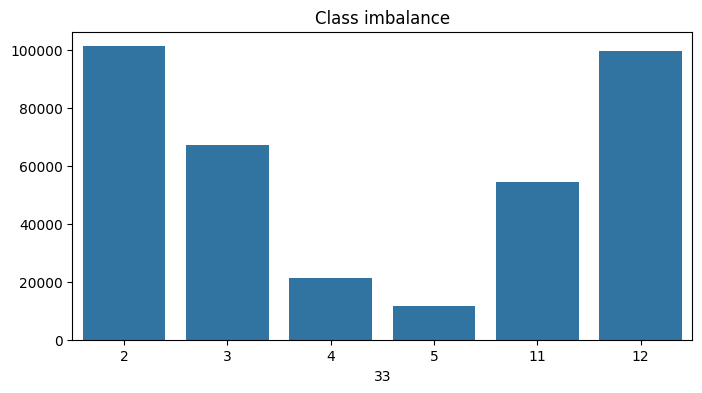

In [16]:
# Class distribution
target_col = df.columns[-1] 
class_counts = df[target_col].value_counts()
class_pct = df[target_col].value_counts(normalize=True) * 100

print("--- Class distribution ---")
for cls, count in class_counts.items():
    print(f"Class {cls}: {count} samples ({class_pct[cls]:.2f}%)")

plt.figure(figsize=(8, 4))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Class imbalance")
plt.show()

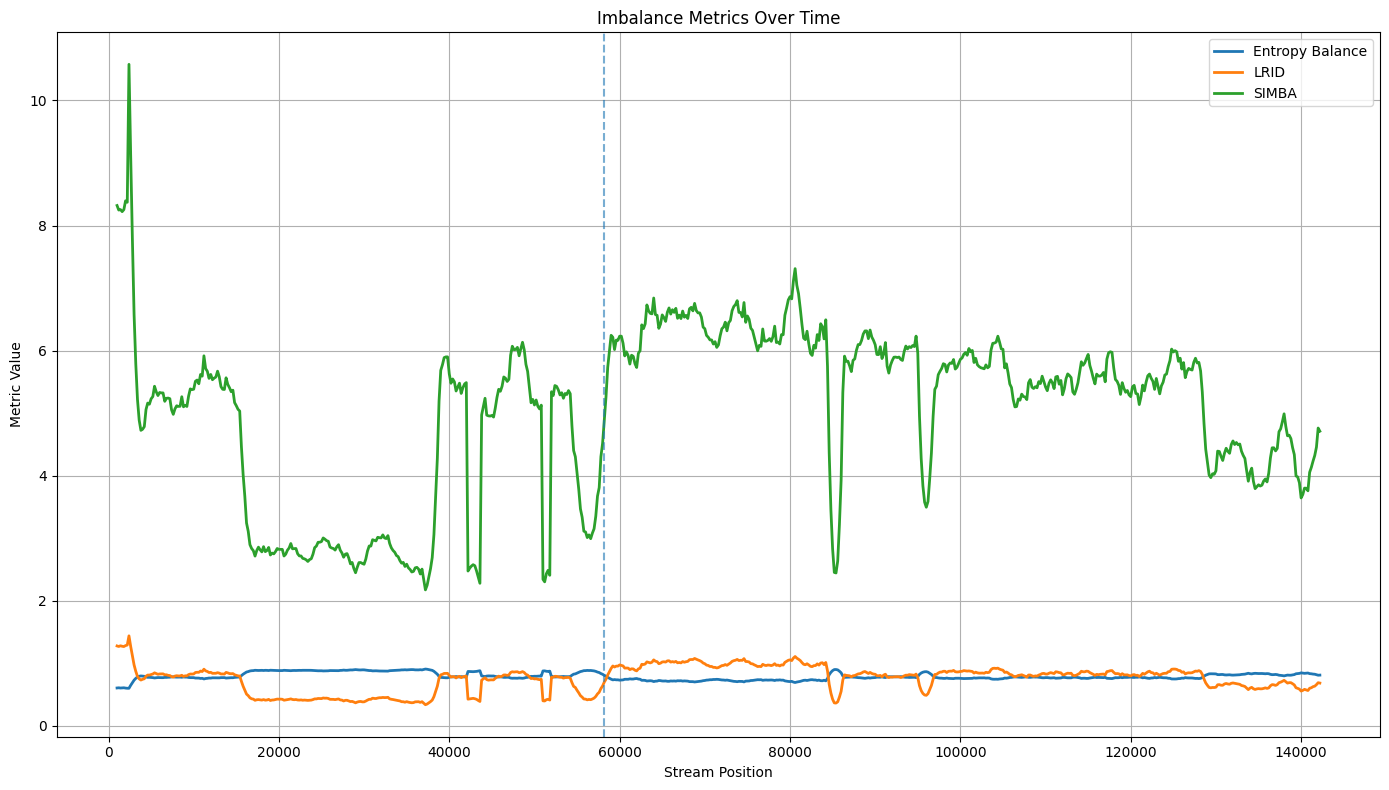

In [ ]:
metrics_df = compute_window_imbalance_metrics(X_df,y_series,window_size=2000,step_size=200)
plot_imbalance_metrics(metrics_df,drift_points=ground_truth_drifts)


--- Top-5 most variable features ---
        mean       std        cv
32  0.079995  0.123174  1.539770
31  0.096133  0.142950  1.487005
30  0.119489  0.172329  1.442215
18  0.201588  0.290277  1.439953
26  0.126822  0.182542  1.439352


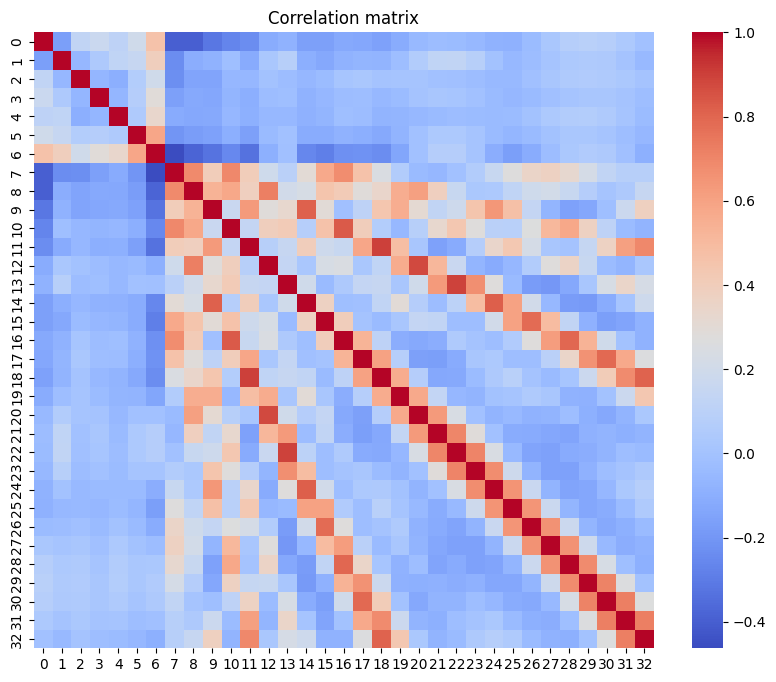

In [49]:
# Correlation matrix
stats = df.iloc[:, :-1].describe().T
stats['cv'] = stats['std'] / stats['mean'] 
features = stats.sort_values(by='cv', ascending=False).head(5).index.tolist()
print("\n--- Top-5 most variable features ---")
print(stats.sort_values(by='cv', ascending=False)[['mean', 'std', 'cv']].head())

plt.figure(figsize=(10, 8))
sns.heatmap(df.iloc[:, :-1].corr(), annot=False, cmap='coolwarm')
plt.title("Correlation matrix")
plt.show()

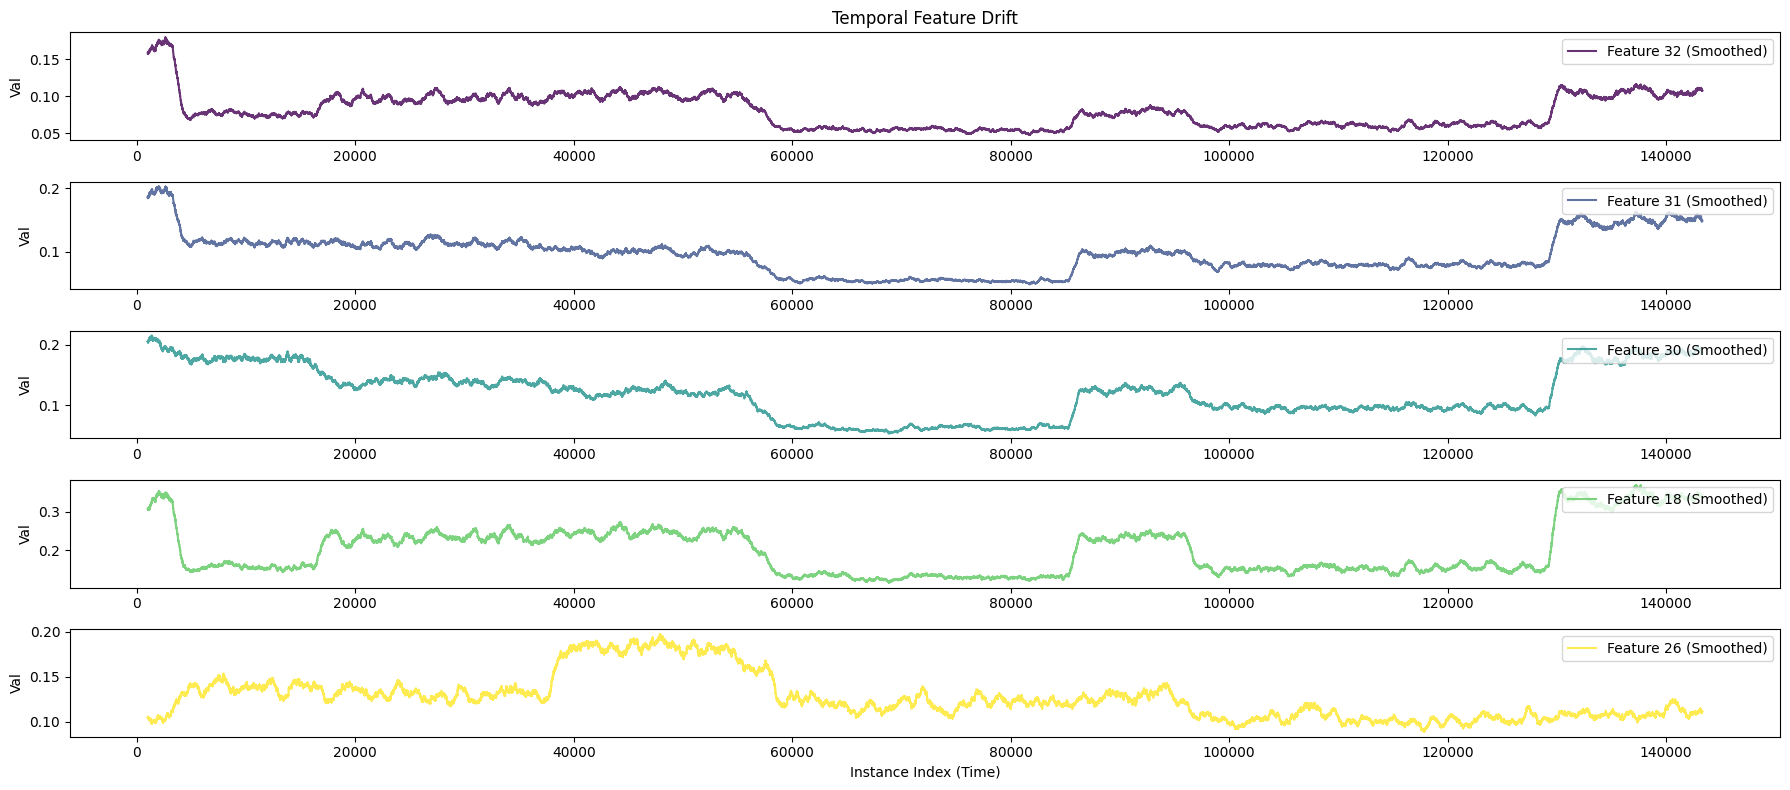

In [50]:
window_size = 1000

plt.figure(figsize=(18, 8))

for i, col in enumerate(features):

    series = X_df[col].rolling(window=window_size).mean() # Moving average to smooth out noise
    
    plt.subplot(len(features), 1, i+1)
    plt.plot(series, label=f'Feature {col} (Smoothed)', color=plt.cm.viridis(i / 4), alpha=0.8)
    plt.ylabel(f'Val')
    plt.legend(loc='upper right')
    if i == 0:
        plt.title('Temporal Feature Drift')

plt.xlabel('Instance Index (Time)')
plt.tight_layout()
plt.show()

### Drift Detection

In [ ]:
n_runs = 1
#stream_type = "insects_abrupt" # insects_abrupt, insects_gradual
stream_type = "insects_gradual" 
#ground_truth_drifts = [83859, 128651, 182320, 242883, 268380] # abrupt
ground_truth_drifts=[58159] # gradual

n_features = 33
n_classes = 6

detectors = [
    ("DDM", lambda: DDMWrapper()),
    ("PH",lambda:PHWrapper()),
    ("D3",lambda:D3(threshold=0.6)),
    ("KSWIN",lambda: PCAKSWIN(n_components=4,alpha=0.0001, window_size=1000, stat_size=100)),
    ("ADWIN",lambda: ADWINError()),
    ("AEDD",lambda: ADWIN_AE(n_features=n_features, delta=0.05)), 
    ("NT",lambda: None)
]

results = {}

for name, detector in detectors:
    print(f"Evaluating detector: {name}")
    results[name] = run_multiple_experiments(
        stream_type=stream_type,
        n_classes=n_classes,
        n_features=n_features,
        ground_truth_drifts=ground_truth_drifts,
        classifier_factory=lambda: tree.HoeffdingTreeClassifier(),
        detector_factory=detector,
        reset_on_drift=True,
        n_runs=n_runs
    )
    print_summary(results[name]["metrics"], name)


In [52]:
for name, res in results.items():
    print_summary(res["metrics"], name)


NoChange
Accuracy            : 0.5634 ± 0.0000
G-Mean              : 0.4482 ± 0.0000
Delay               : 0.0000 ± 0.0000
Recall              : 0.0000 ± 0.0000
Precision           : 0.0000 ± 0.0000
FAR                 : 0.0000 ± 0.0000
HDD                 : 0.0000 ± 0.0000

DDM
Accuracy            : 0.6093 ± 0.0000
G-Mean              : 0.5209 ± 0.0000
Delay               : 27513.0000 ± 0.0000
Recall              : 1.0000 ± 0.0000
Precision           : 0.0385 ± 0.0000
FAR                 : 0.9615 ± 0.0000
HDD                 : 0.0741 ± 0.0000

ADWIN Entropy
Accuracy            : 0.5628 ± 0.0000
G-Mean              : 0.5286 ± 0.0000
Delay               : 4288.0000 ± 0.0000
Recall              : 1.0000 ± 0.0000
Precision           : 0.0204 ± 0.0000
FAR                 : 0.9796 ± 0.0000
HDD                 : 0.0400 ± 0.0000

ADWIN Error
Accuracy            : 0.5718 ± 0.0000
G-Mean              : 0.5385 ± 0.0000
Delay               : 2811.0000 ± 0.0000
Recall              : 1.0000 ± 0.00

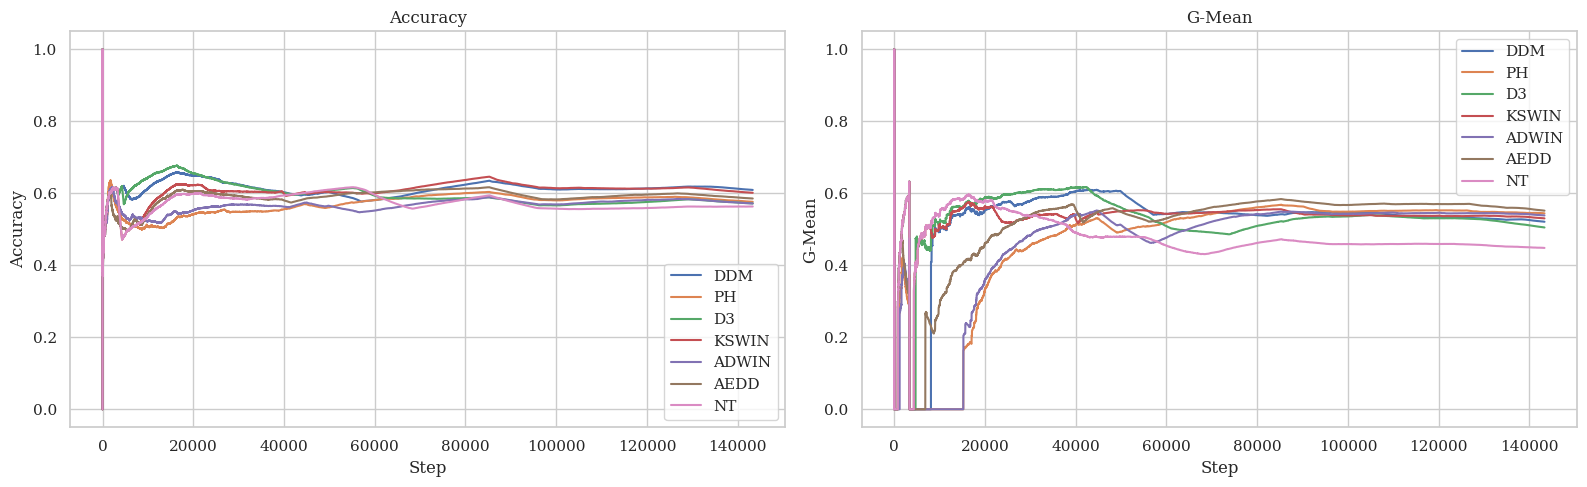

In [28]:
run = 0  

results_for_plot = {
    name: {
        "tracker": data["all_trackers"][run],
        "drifts": data["all_drifts"][run]
    }
    for name, data in results.items()
}

plot_metrics(results_for_plot)

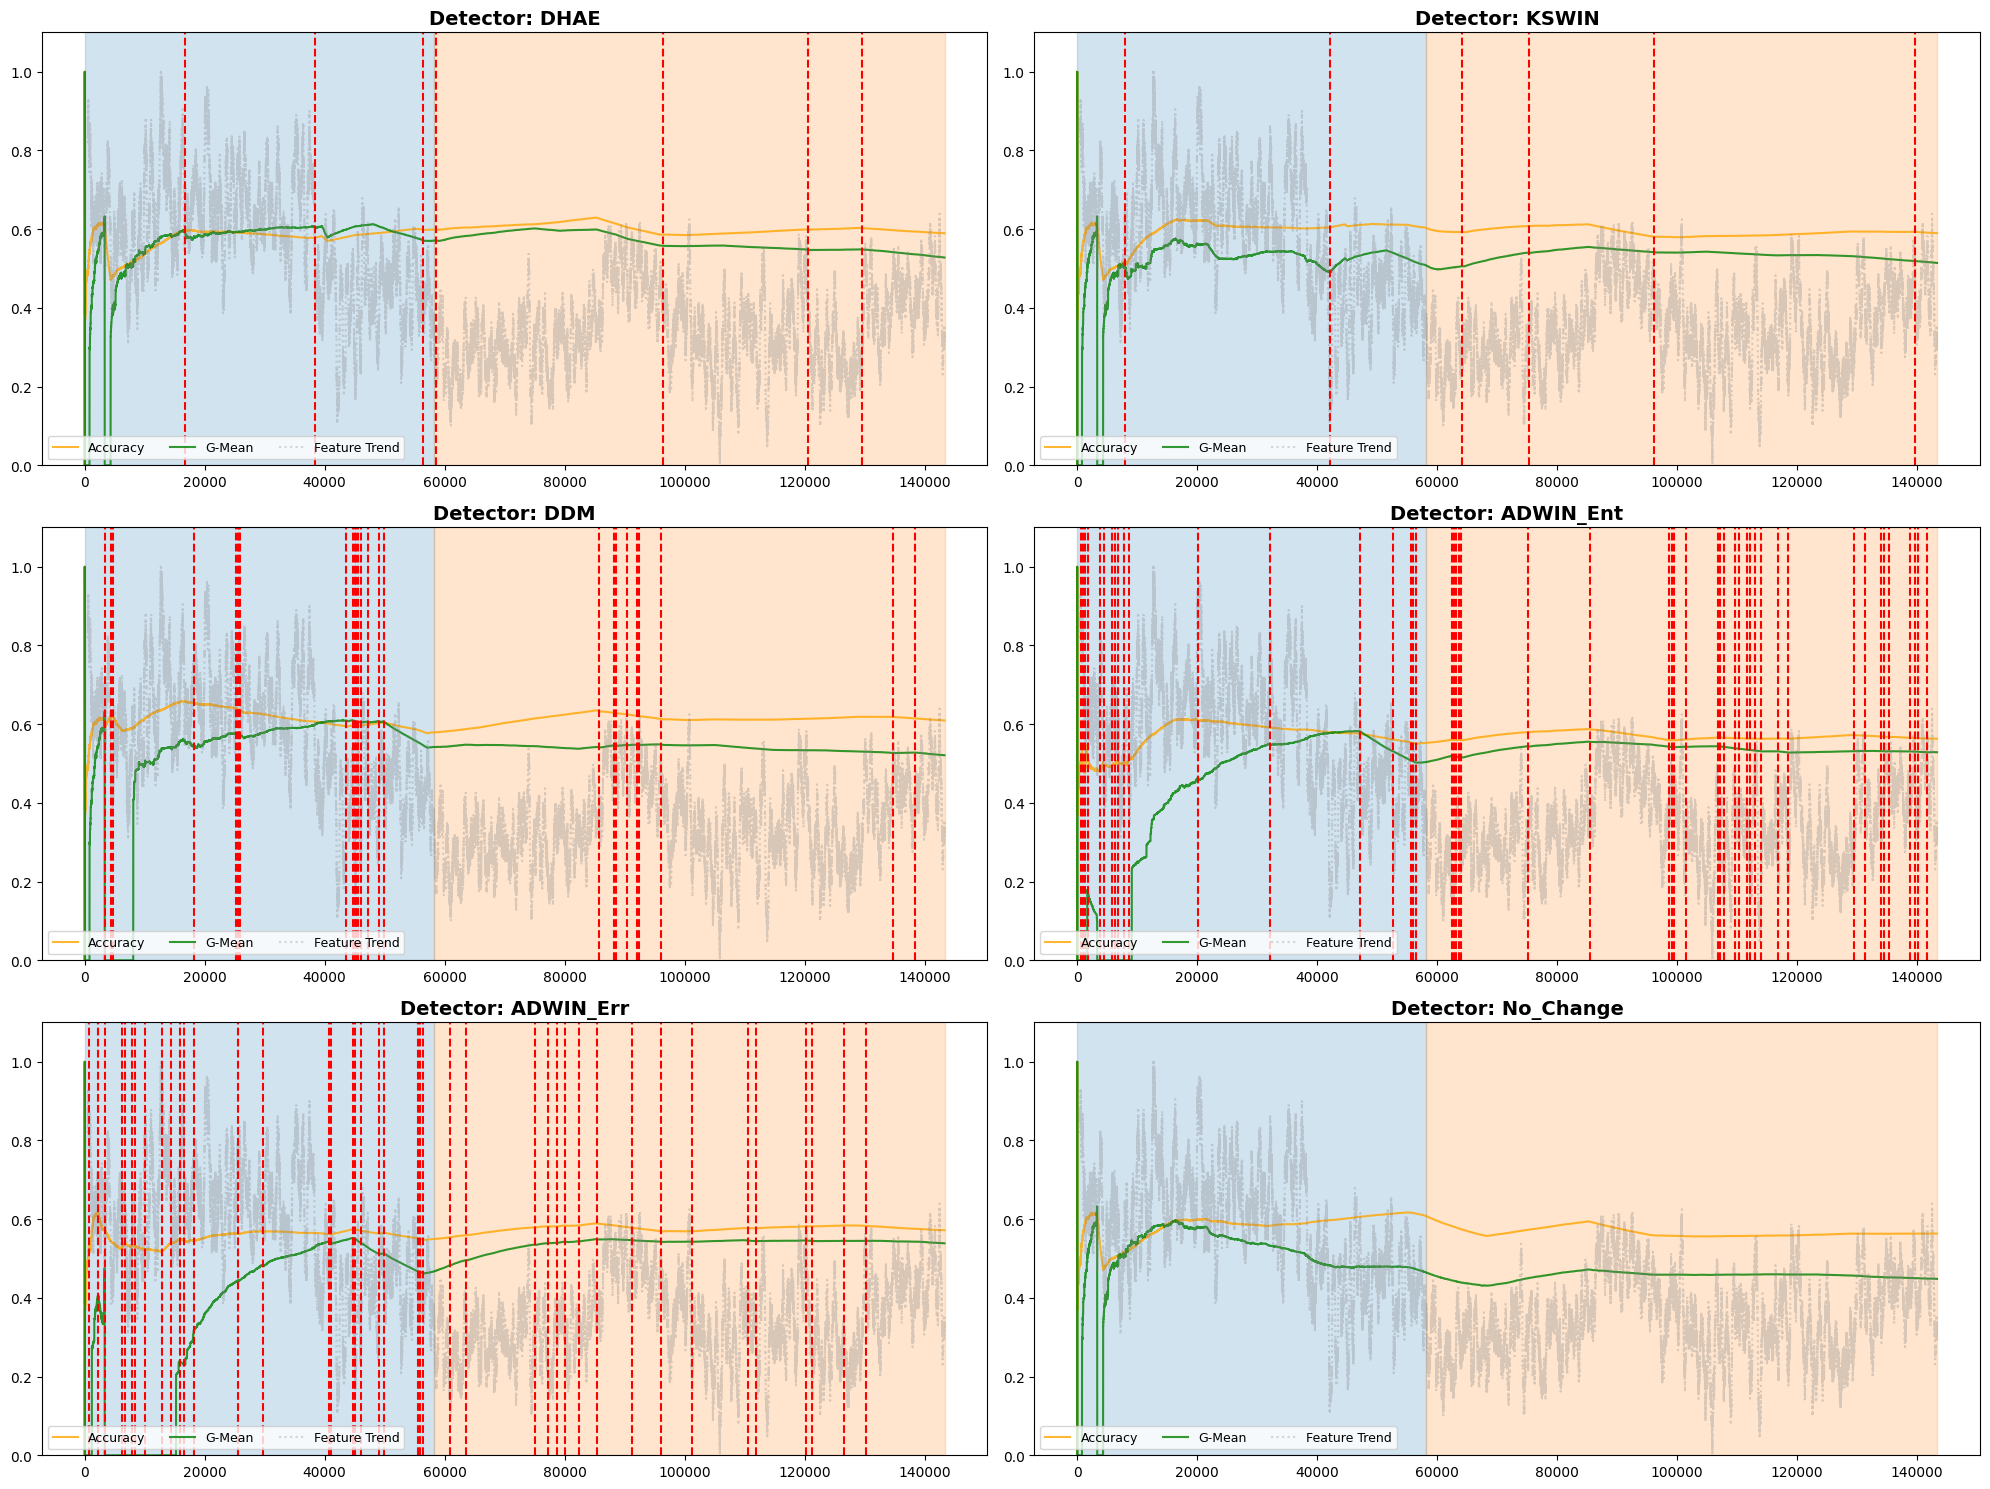

In [86]:
plot_detection_results(results, ground_truth_drifts, X_df=X_df, feature_idx=2)

## Random RBF dataset

### Exploratoin

In [ ]:
n_classes= 8
n_features = 30
n_samples= 100000

drift_width=1000

#scenario = [{0: 1, 1: 1, 2: 1, 3: 1, 4: 1, 5: 1, 6: 1, 7: 1}] # balanced
#scenario = [{0: 0.20, 1: 0.18, 2: 0.16, 3: 0.14, 4: 0.12, 5: 0.10, 6: 0.08, 7: 0.02}] # moderate ~ 1:10
scenario = [{0: 0.60, 1: 0.12, 2: 0.08, 3: 0.06, 4: 0.05,5: 0.04, 6: 0.03, 7: 0.02}] # severe ~ 1:30

ground_truth_drifts=[20000, 40000, 60000, 80000]

stream = RBFDriftStream(
    n_classes=n_classes, 
    n_features= n_features,
    drift_points=ground_truth_drifts, 
    drift_width=drift_width, 
    imbalance_configs=scenario
)

df = stream_to_df(stream, n_samples)

X_df = df.iloc[:, :-1]
y_series = df.iloc[:,-1] 

print(f"Number of features: {n_features}") 
print(f"Number of samples: {n_samples}")
print(f"Number of classes: {n_classes}")
df.head()


Number of features: 30
Number of samples: 100000
Number of classes: 8


,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,label
0,0.201824,0.857750,0.380218,0.238192,0.408241,0.265239,0.645951,0.447974,0.818566,0.346764,...,0.900335,0.721951,0.267809,0.769954,0.471839,0.796595,0.716262,0.552694,0.828767,1
1,0.983031,0.427811,0.611548,0.802753,0.678939,0.831251,0.602264,0.730845,0.078137,0.231644,...,0.676704,0.659300,0.210044,0.734980,0.113625,0.359710,1.019068,0.645726,0.614633,5
2,0.626524,0.525758,0.753794,0.760131,0.083498,0.703095,0.431317,0.528627,0.831739,0.210775,...,0.499204,0.424487,0.490375,0.094812,0.183817,0.456284,0.389074,0.311182,0.946521,0
3,0.344442,0.648252,0.495814,0.985269,0.065216,0.850695,0.099056,0.373756,0.763225,0.476540,...,0.515506,0.796326,0.068357,0.488729,0.818192,0.778844,0.503343,0.290303,0.178067,3
4,0.166575,-0.013320,0.257059,0.291683,0.144688,0.972360,0.832880,0.371033,0.627523,0.394746,...,0.463160,0.097633,0.018084,0.069306,0.632787,0.831056,0.421080,-0.002852,0.390128,7


--- Class distribution ---
Class 0: 59964 samples (59.96%)
Class 1: 12000 samples (12.00%)
Class 2: 8000 samples (8.00%)
Class 3: 6000 samples (6.00%)
Class 4: 5000 samples (5.00%)
Class 5: 4000 samples (4.00%)
Class 6: 3000 samples (3.00%)
Class 7: 2036 samples (2.04%)


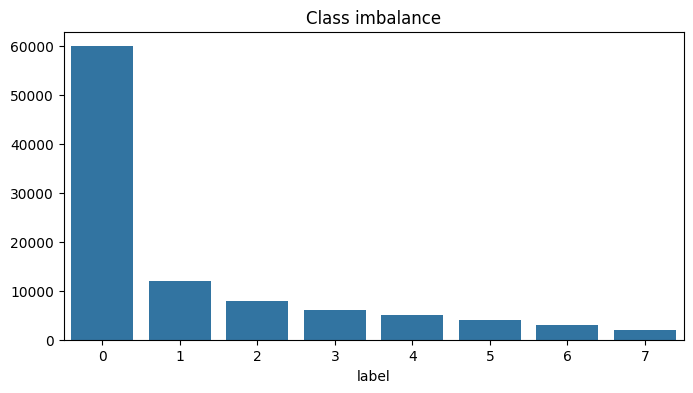

In [23]:
# Class distribution
target_col = df.columns[-1] 
class_counts = df[target_col].value_counts()
class_pct = df[target_col].value_counts(normalize=True) * 100

print("--- Class distribution ---")
for cls, count in class_counts.items():
    print(f"Class {cls}: {count} samples ({class_pct[cls]:.2f}%)")

plt.figure(figsize=(8, 4))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Class imbalance")
plt.show()

In [24]:
print(f"Entropy of class proportions: {calculate_entropy_balance(class_counts):.4f}")
print(f"SIMBA: {calculate_simba(X_df, y_series):.4f}")
print(f"LRID_norm: {calculate_lrid_norm(class_counts):.4f}")

Entropy of class proportions: 0.6708
SIMBA: 24.5379
LRID_norm: 1.3689


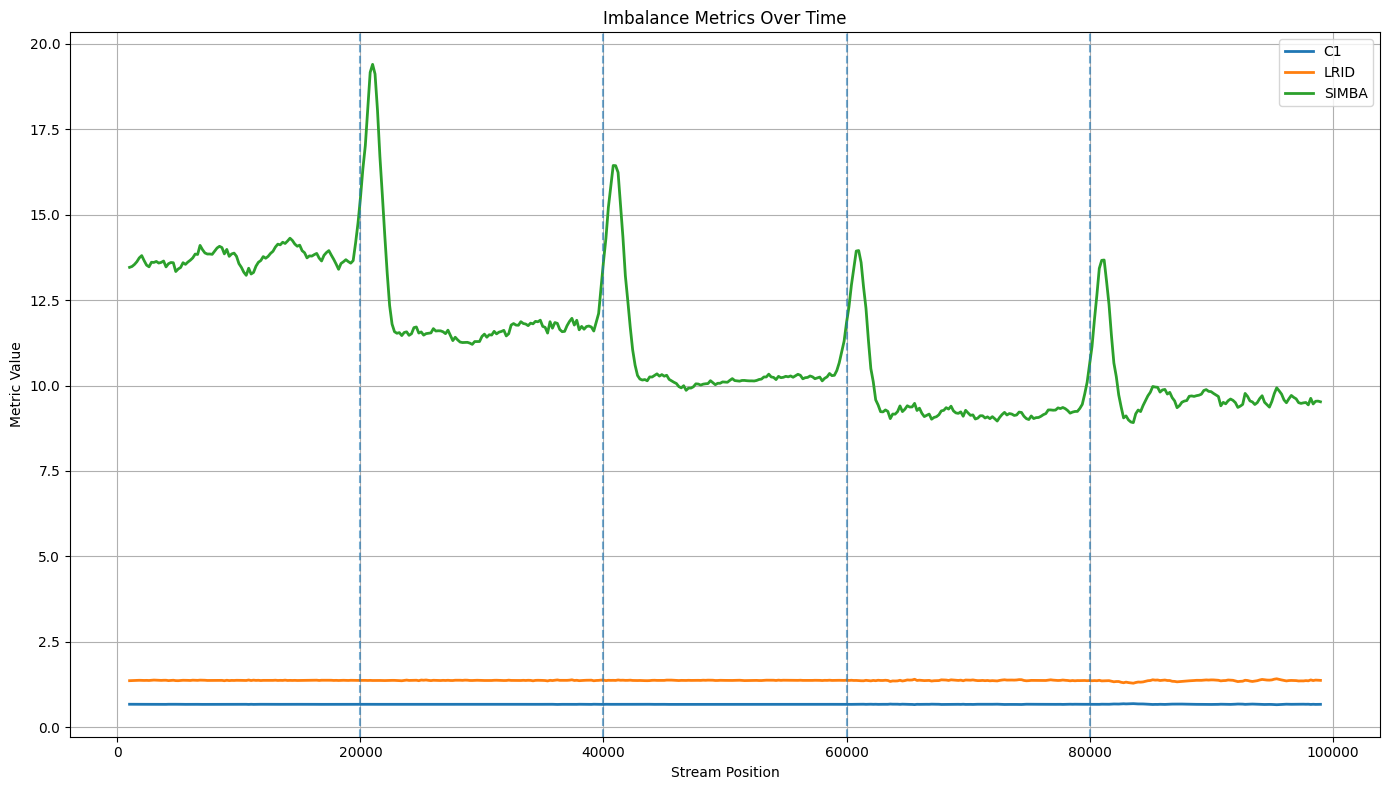

In [27]:
metrics_df = compute_window_imbalance_metrics(X_df,y_series,window_size=2000,step_size=200)
plot_imbalance_metrics(metrics_df,drift_points=ground_truth_drifts)

In [25]:
stats = df.iloc[:, :-2].describe().T
stats['cv'] = stats['std'] / stats['mean'] 
features = stats.sort_values(by='cv', ascending=False).head(5).index.tolist()
print("\n--- Top-5 most variable features ---")
print(stats.sort_values(by='cv', ascending=False)[['mean', 'std', 'cv']].head())


--- Top-5 most variable features ---
        mean       std        cv
19  0.405784  0.325201  0.801415
5   0.412215  0.326848  0.792907
24  0.394822  0.304324  0.770789
11  0.464435  0.327125  0.704350
13  0.444498  0.309901  0.697192


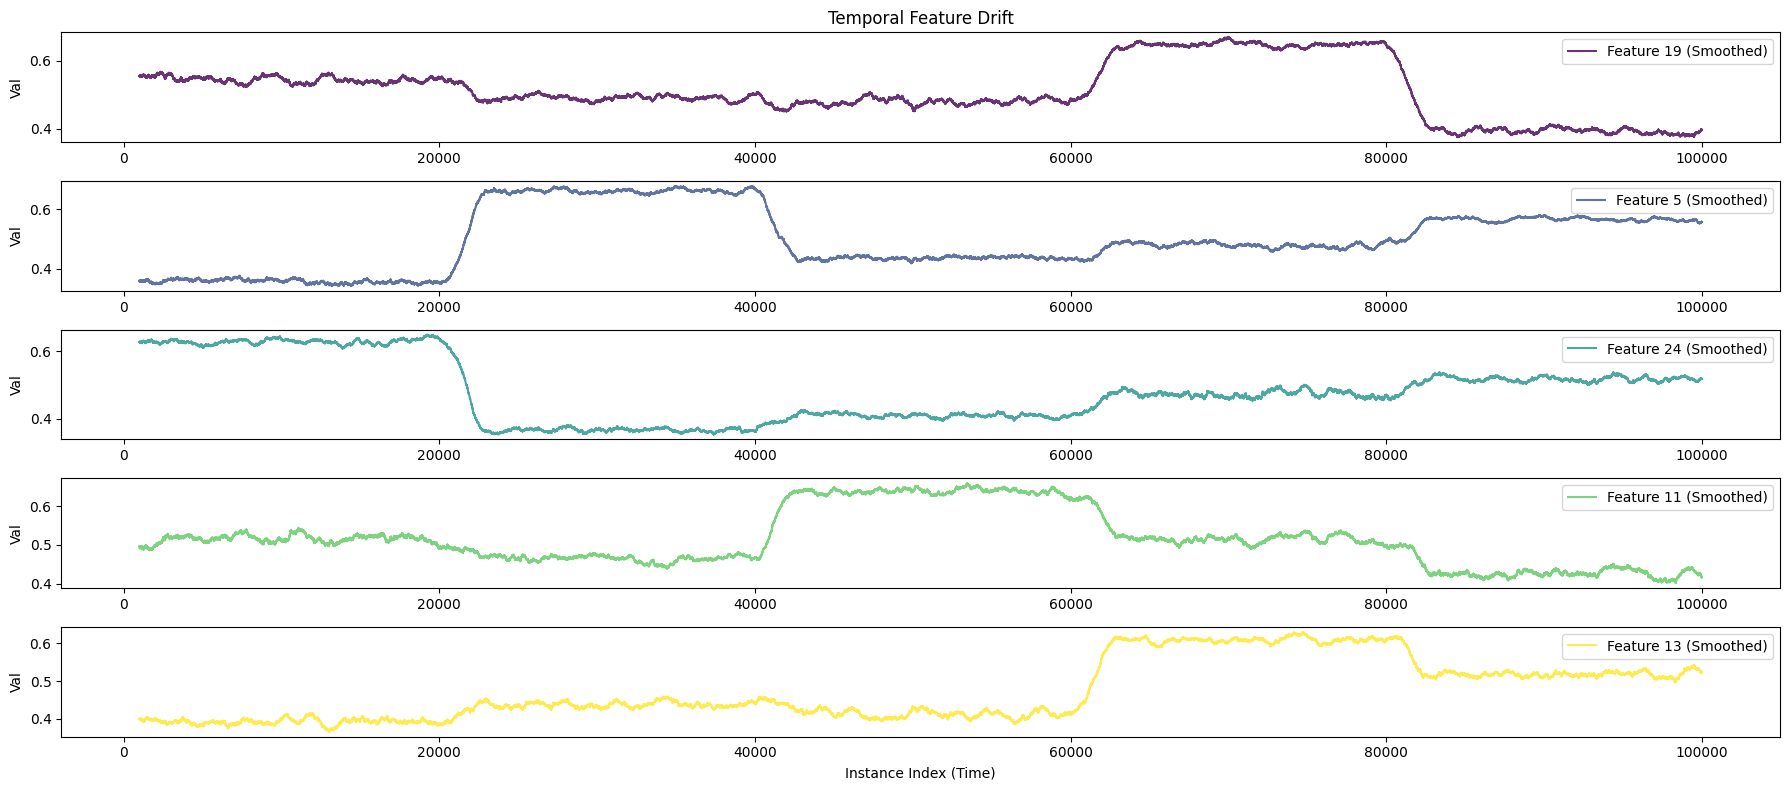

In [26]:
window_size = 1000

plt.figure(figsize=(18, 8))

for i, col in enumerate(features):

    series = X_df.iloc[:, i].rolling(window=window_size).mean()
    
    plt.subplot(len(features), 1, i+1)
    plt.plot(series, label=f'Feature {col} (Smoothed)', color=plt.cm.viridis(i / 4), alpha=0.8)
    plt.ylabel(f'Val')
    plt.legend(loc='upper right')
    if i == 0:
        plt.title('Temporal Feature Drift')

plt.xlabel('Instance Index (Time)')
plt.tight_layout()
plt.show()

### Drift Detection

======= experiment settings ======
dataset: rbf (samples: 50000  classes: 8 )
imbalance:  [{0: 0.2, 1: 0.18, 2: 0.16, 3: 0.14, 4: 0.12, 5: 0.1, 6: 0.08, 7: 0.02}]
drift width:  1
ground truth drifts:  [10000, 20000, 30000, 40000]
Running seed:  0
!!! Drift at 10120 (score= 0.2586). Adapting
--- Resume monitoring at step 10620 ---
!!! Drift at 20124 (score= 0.1624). Adapting
--- Resume monitoring at step 20624 ---
!!! Drift at 30128 (score= 0.3583). Adapting
--- Resume monitoring at step 30628 ---
!!! Drift at 40100 (score= 0.2120). Adapting
--- Resume monitoring at step 40600 ---

AE
Accuracy            : 0.8716 ± 0.0000
G-Mean              : 0.8421 ± 0.0000
Delay               : 117.0000 ± 0.0000
Recall              : 1.0000 ± 0.0000
Precision           : 1.0000 ± 0.0000
FAR                 : 0.0000 ± 0.0000
HDD                 : 1.0000 ± 0.0000


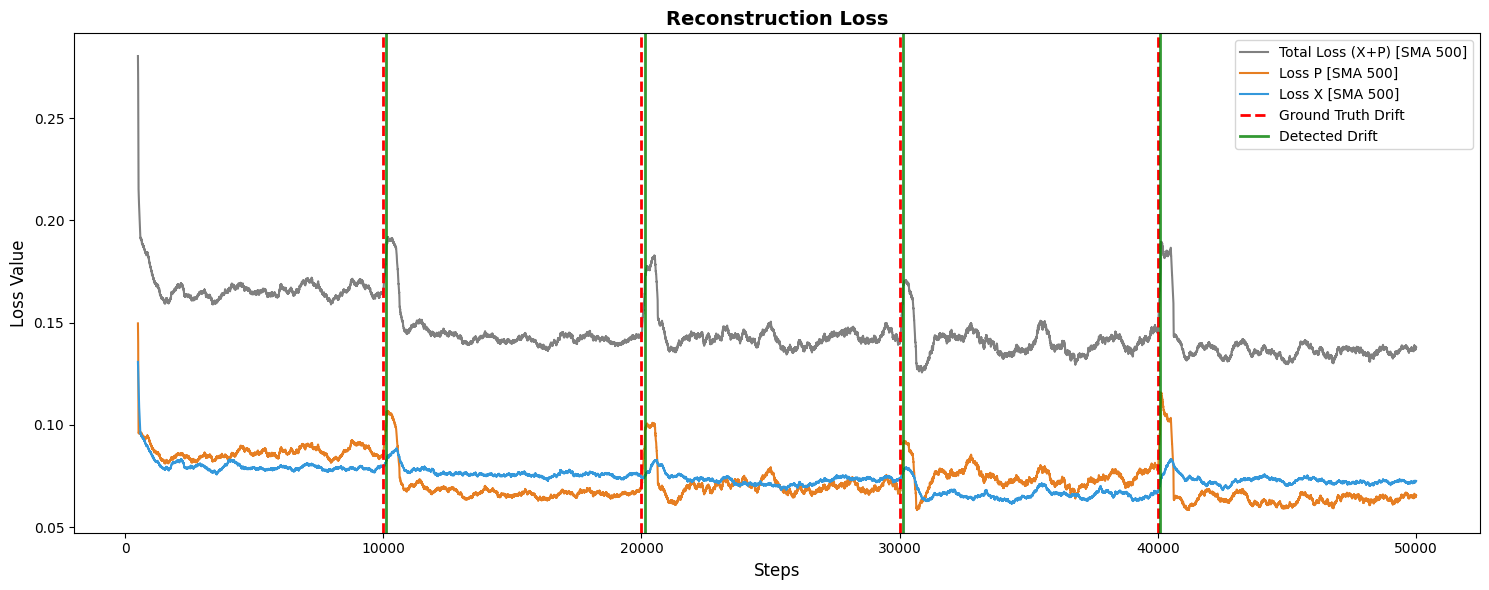

In [ ]:
#scenario = [{0: 1, 1: 1, 2: 1, 3: 1, 4: 1, 5: 1, 6: 1, 7: 1}] # balanced
scenario = [{0: 0.20, 1: 0.18, 2: 0.16, 3: 0.14, 4: 0.12, 5: 0.10, 6: 0.08, 7: 0.02}] # moderate ~ 1:10
#scenario = [{0: 0.60, 1: 0.12, 2: 0.08, 3: 0.06, 4: 0.05,5: 0.04, 6: 0.03, 7: 0.02}] # severe ~ 1:30

test_dhae = DHAEv5(n_features=30, n_classes=8)
ground_truth_drifts=[10000,20000,30000,40000]

results_dhae= run_multiple_experiments(
    stream_type="rbf",
    n_classes=8,
    n_features=30,
    drift_width=1,
    ground_truth_drifts=ground_truth_drifts,
    n_samples=50000,
    imbalance_configs=scenario,
    classifier_factory=lambda: tree.HoeffdingTreeClassifier(),
    detector_factory=lambda: test_dhae, 
    reset_on_drift=True,
    n_runs=1
)
print_summary(results_dhae["metrics"], "AE")
detected_drifts = results_dhae["all_drifts"][0] 
plot_loss_breakdown(test_dhae, ground_truth_drifts, detected_drifts=detected_drifts, window=500)

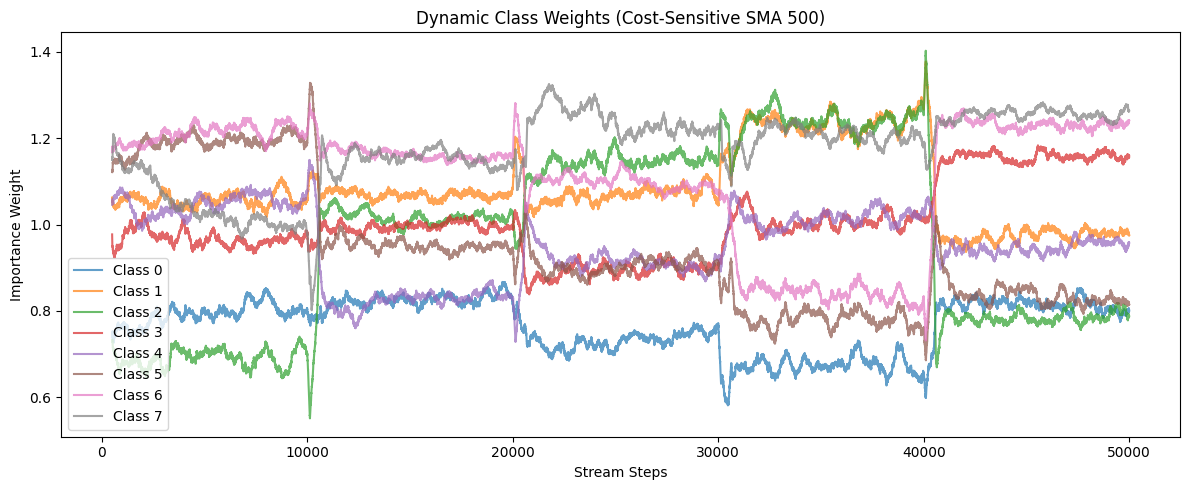

In [ ]:
def plot_weight_dynamics(dhae, window=500):
    raw_weights = np.array(dhae.weights_history)
    
    if raw_weights.ndim == 3:
        raw_weights = raw_weights.squeeze(axis=1)
    
    df_weights = pd.DataFrame(raw_weights)
    
    weights_smoothed = df_weights.rolling(window=window).mean()

    plt.figure(figsize=(12, 5))
    steps = range(len(weights_smoothed))
    n_classes = weights_smoothed.shape[1]
    
    for i in range(n_classes):
        plt.plot(steps, weights_smoothed.iloc[:, i], label=f'Class {i}', alpha=0.7)

    plt.title(f"Dynamic Class Weights (Cost-Sensitive SMA {window})")
    plt.xlabel("Stream Steps")
    plt.ylabel("Importance Weight")
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_weight_dynamics(test_dhae)

Evaluating detector: DDM
======= experiment settings ======
dataset: rbf (samples: 100000  classes: 8 )
imbalance:  [{0: 0.7, 1: 0.11, 2: 0.07, 3: 0.05, 4: 0.03, 5: 0.02, 6: 0.01, 7: 0.01}]
drift width:  1000
ground truth drifts:  [20000, 40000, 60000, 80000]
Running seed:  0
Running seed:  1
Running seed:  2
Running seed:  3
Running seed:  4

DDM
Prediction Accuracy : 90.7880 ± 1.0142
Prediction G-Mean   : 73.0620 ± 2.4166
Kappa               : 0.8063 ± 0.0209
MTD (Delay)         : 471.8000 ± 40.1371
MTFA                : 12833.3020 ± 4744.2218
MTR                 : 27.0438 ± 9.5628
Recall              : 100.0000 ± 0.0000
Precision           : 33.2680 ± 8.5819
FAR                 : 66.7320 ± 8.5819
HDD                 : 49.2900 ± 9.9039
Latency_ms          : 0.9161 ± 0.0716
Evaluating detector: PH
======= experiment settings ======
dataset: rbf (samples: 100000  classes: 8 )
imbalance:  [{0: 0.7, 1: 0.11, 2: 0.07, 3: 0.05, 4: 0.03, 5: 0.02, 6: 0.01, 7: 0.01}]
drift width:  1000
ground

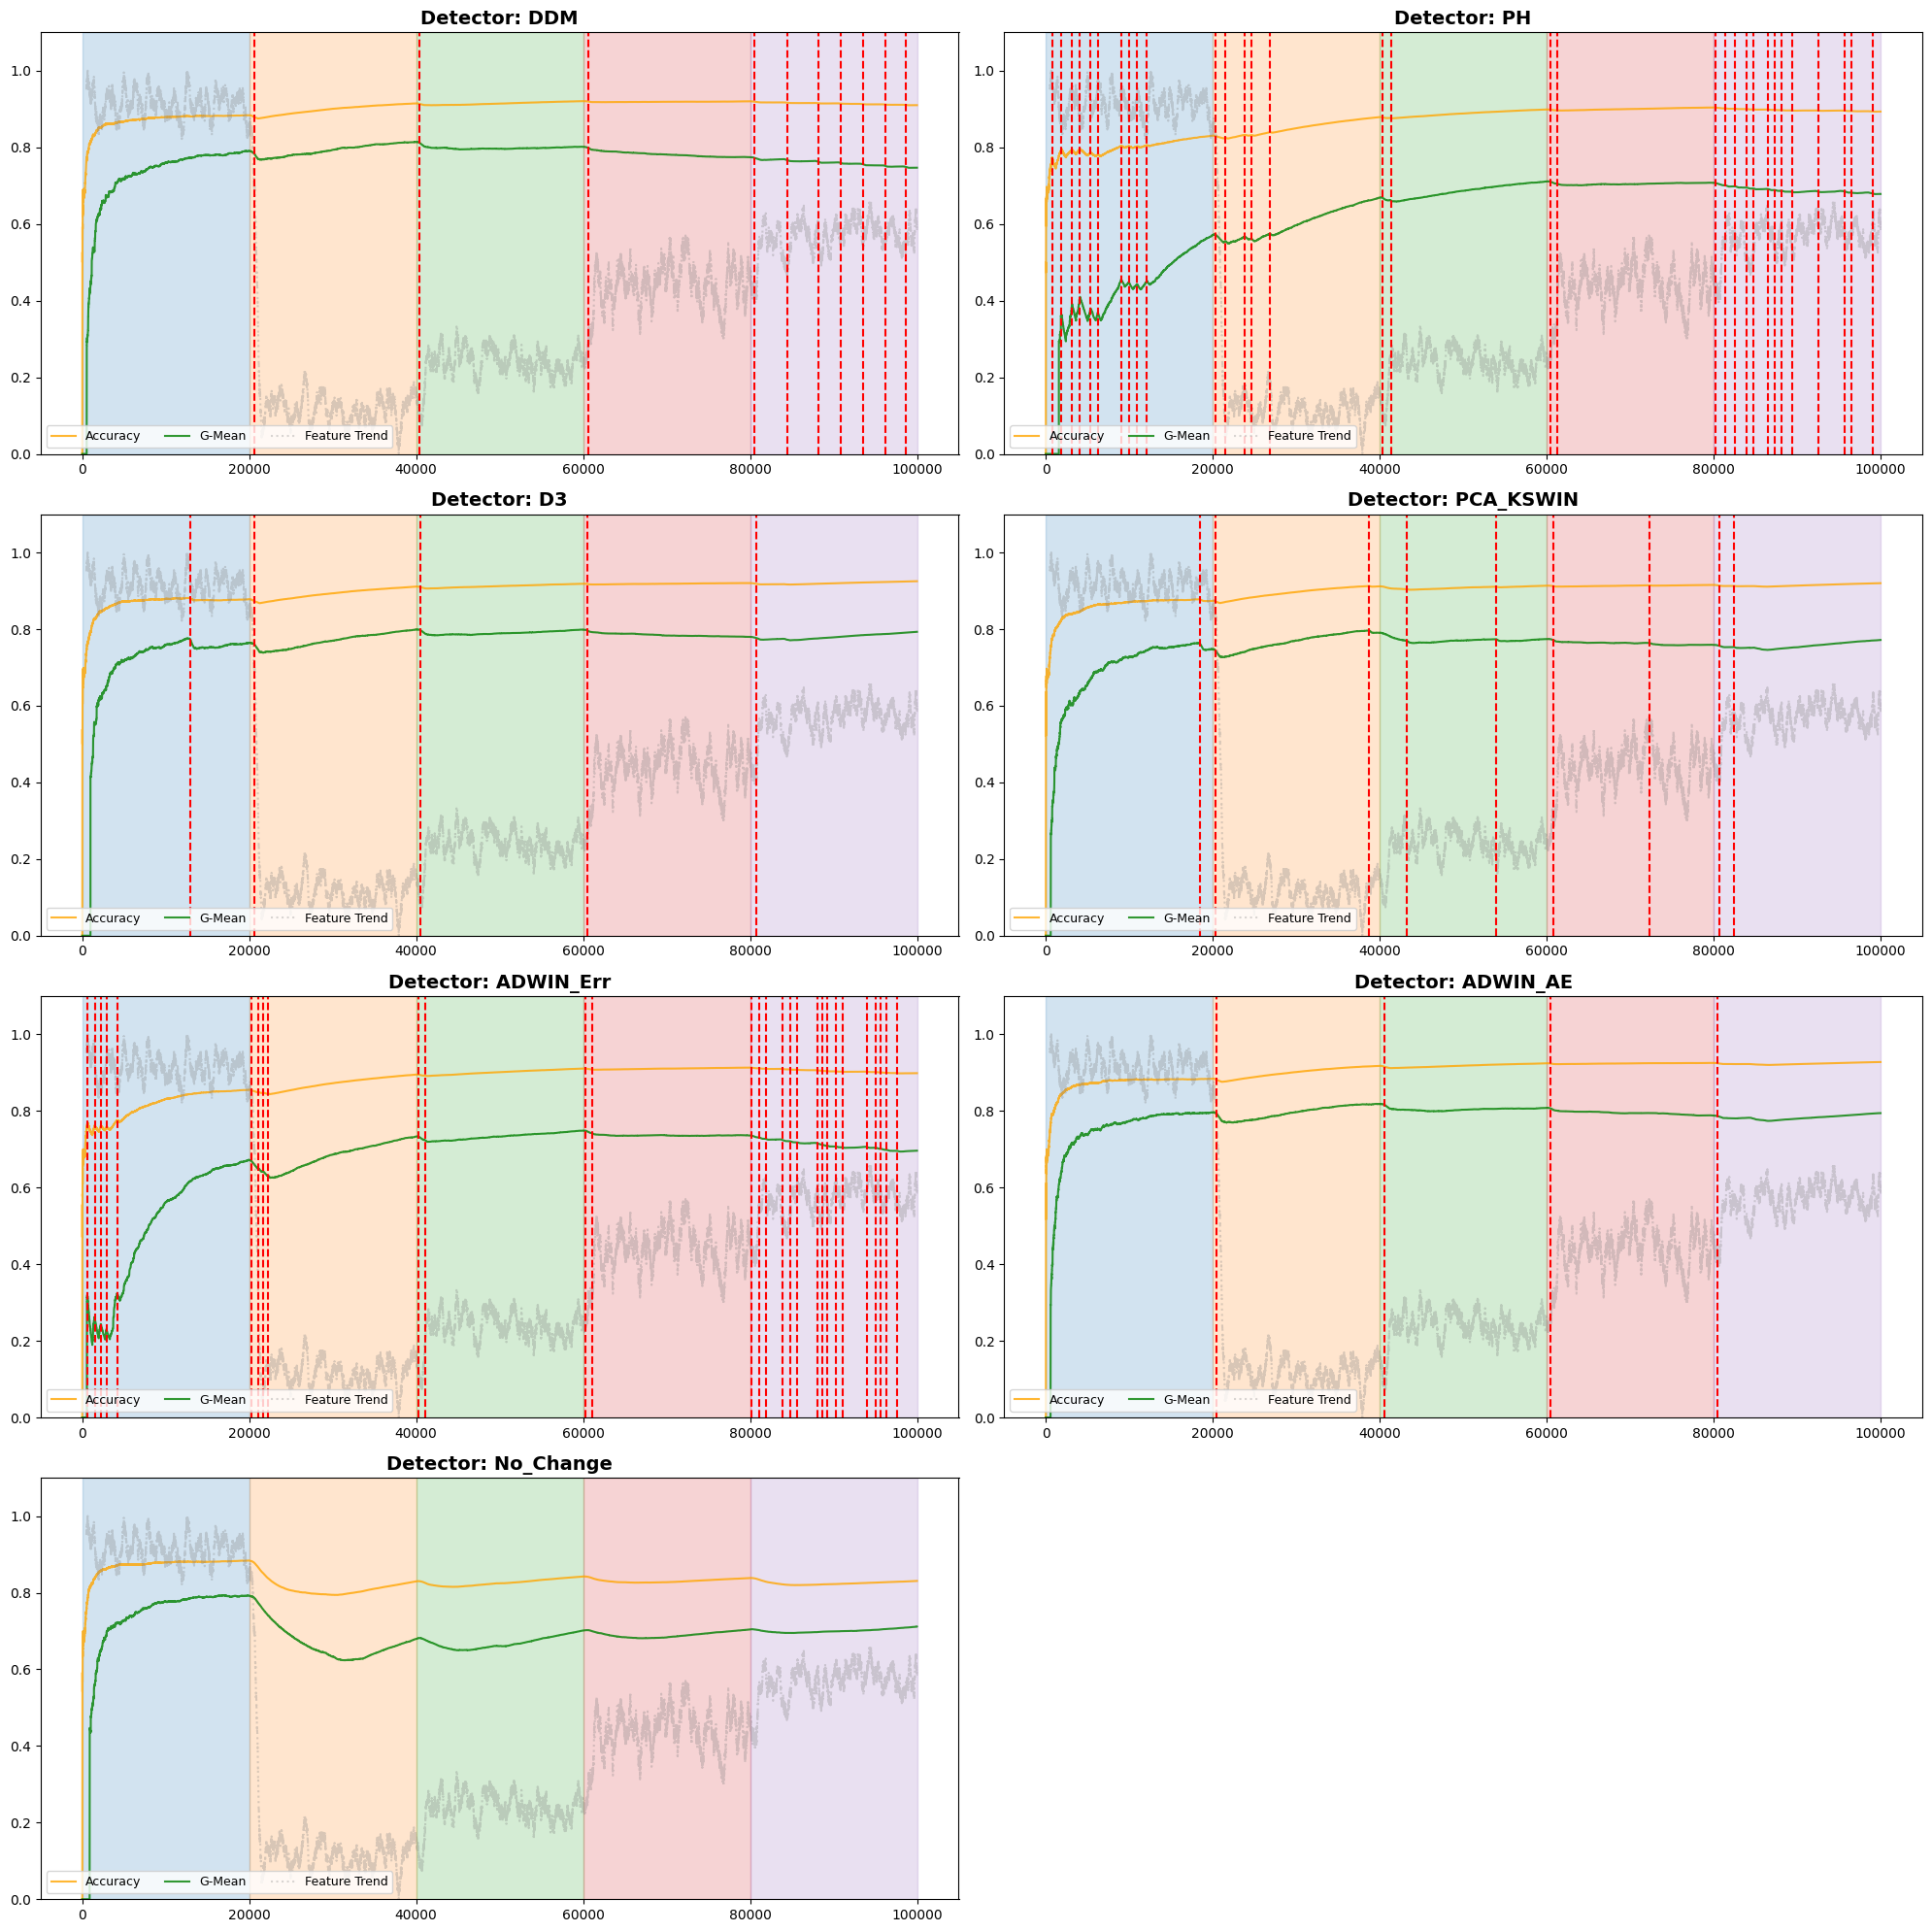

In [ ]:
n_runs = 5

n_classes= 8
n_features = 30
n_samples= 100000
ground_truth_drifts=[20000,40000,60000,80000]

stream_type = "rbf" #rbf, insects_abrupt, insects_gradual

drift_width=1

irs= [
    ("1:1",  [{0: 1, 1: 1, 2: 1, 3: 1, 4: 1, 5: 1, 6: 1, 7: 1}]),
    ("1:10", [{0: 0.20, 1: 0.18, 2: 0.16, 3: 0.14, 4: 0.12, 5: 0.10, 6: 0.08, 7: 0.02}] ),
    ("1:20", [{0: 0.50, 1: 0.15, 2: 0.10, 3: 0.08, 4: 0.06, 5: 0.05, 6: 0.035, 7: 0.025}]),
    ("1:30", [{0: 0.60, 1: 0.12, 2: 0.08, 3: 0.06, 4: 0.05,5: 0.04, 6: 0.03, 7: 0.02}] ),
    ("1:40", [{0: 0.60, 1: 0.12, 2: 0.09, 3: 0.07, 4: 0.05, 5: 0.035, 6: 0.02, 7: 0.015}]),
    ("1:50", [{0: 0.65, 1: 0.12, 2: 0.08, 3: 0.06, 4: 0.04, 5: 0.025, 6: 0.012, 7: 0.013}]),
    ("1:60", [{0: 0.60, 1: 0.15, 2: 0.10, 3: 0.06, 4: 0.04, 5: 0.02, 6: 0.02, 7: 0.01}]),
    ("1:70", [{0: 0.70, 1: 0.11, 2: 0.07, 3: 0.05, 4: 0.03, 5: 0.02, 6: 0.01, 7: 0.01}]),
    ("1:80", [{0: 0.72, 1: 0.116, 2: 0.08, 3: 0.04, 4: 0.02, 5: 0.01, 6: 0.005, 7: 0.009}]),
    ("1:90", [{0: 0.72, 1: 0.117, 2: 0.08, 3: 0.04, 4: 0.02, 5: 0.01, 6: 0.005, 7: 0.008}]),
    ("1:100",[{0: 0.70, 1: 0.12, 2: 0.08, 3: 0.05, 4: 0.025, 5: 0.01, 6: 0.008, 7: 0.007}] )
]

detectors = [
    ("DDM", lambda: DDMWrapper()),
    ("PH",lambda:PHWrapper()),
    ("D3",lambda:D3(threshold=0.6)),
    ("PCA_KSWIN",lambda: PCAKSWIN(n_components=4,alpha=0.0001, window_size=1000, stat_size=100)),
    ("ADWIN_Ent", lambda: ADWINEntropy(n_classes=n_classes)),
    ("ADWIN_Err",lambda: ADWINError()),
    ("ADWIN_AE",lambda: ADWIN_AE(n_features=n_features, delta=0.05)), 
    ("No_Change",lambda: NoChangeDetector(1000))
    ("DHAEv5",lambda: DHAEv5(n_features=n_features, n_classes=n_classes, delta=0.0005)) #WCE+MSE
]

results = {}

for name, ir in irs:
    print(f"Imbalance ratio: {name}")
    results[name] = run_multiple_experiments(
        stream_type=stream_type,
        n_classes=n_classes,
        n_features=n_features,
        drift_width=drift_width,
        ground_truth_drifts=ground_truth_drifts,
        n_samples=n_samples,
        imbalance_configs=ir,
        classifier_factory=lambda: tree.HoeffdingTreeClassifier(),
        detector_factory=lambda: None,
        reset_on_drift=True,
        n_runs=n_runs
    )
    print_summary(results[name]["metrics"], name)

plot_detection_results(results, ground_truth_drifts, X_df=X_df, feature_idx=2)

In [17]:
for name, res in results.items():
    print_summary(res["metrics"], name)


DDM
Prediction Accuracy : 88.5820 ± 0.7204
Prediction G-Mean   : 80.8960 ± 1.2116
Kappa               : 0.8356 ± 0.0104
MTD (Delay)         : 425.3500 ± 73.2347
MTFA                : 14911.2040 ± 7946.5059
MTR                 : 33.3996 ± 14.0221
Recall              : 100.0000 ± 0.0000
Precision           : 35.3040 ± 12.3476
FAR                 : 64.6960 ± 12.3476
HDD                 : 50.9720 ± 13.3218
Latency_ms          : 1.0408 ± 0.0907

PH
Prediction Accuracy : 88.2200 ± 0.8311
Prediction G-Mean   : 80.0680 ± 1.2819
Kappa               : 0.8302 ± 0.0116
MTD (Delay)         : 338.2000 ± 47.7709
MTFA                : 7270.4580 ± 2827.4089
MTR                 : 22.1433 ± 10.0337
Recall              : 100.0000 ± 0.0000
Precision           : 22.2000 ± 6.4121
FAR                 : 77.8000 ± 6.4121
HDD                 : 35.8980 ± 8.3067
Latency_ms          : 0.9828 ± 0.0538

D3
Prediction Accuracy : 89.7400 ± 0.4678
Prediction G-Mean   : 82.9740 ± 0.6796
Kappa               : 0.8527 ± 0.

## Analysis

In [49]:
df = pd.read_csv("results.csv")
df.head()

,Drift_Type,Environment,IR,Detector,gmean,mtd,mtfa,mtr
0,gradual,Synthetic,1:1,ADWIN,85.60,357.5,13370.1,59.5531
1,gradual,Synthetic,1:1,AEDD,85.28,635.4,97535.2,160.8737
2,gradual,Synthetic,1:1,D3,84.45,559.0,77843.2,117.0034
3,gradual,Synthetic,1:1,DDM,85.94,460.1,88356.4,194.4691
4,gradual,Synthetic,1:1,KSWIN,80.82,586.8,37634.9,18.7495


C:\Users\пк\AppData\Local\Temp\ipykernel_22220\329196482.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_ranked = df_selected.groupby(["Drift_Type", "Environment"], group_keys=False).apply(compute_exact_avg_ranks)


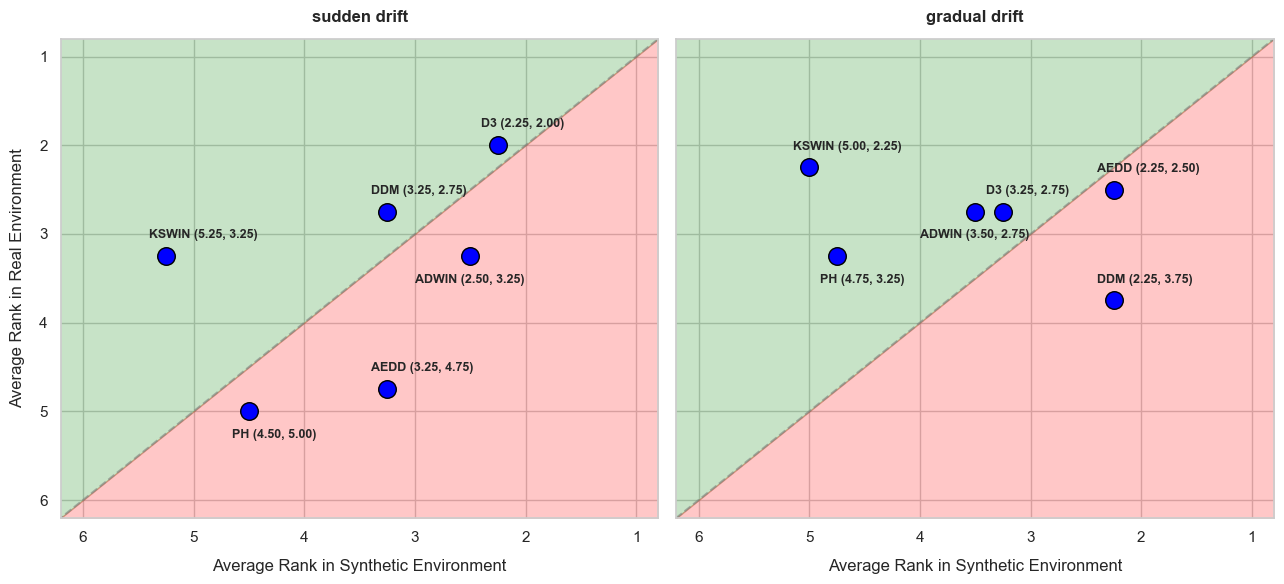

In [ ]:
def compute_exact_avg_ranks(group):
    r_gmean = group["gmean"].rank(ascending=False, method="min")
    r_mtfa = group["mtfa"].rank(ascending=False, method="min")
    r_mtr = group["mtr"].rank(ascending=False, method="min")
    r_mtd = group["mtd"].rank(ascending=True, method="min")
    group["Exact_Avg_Rank"] = (r_gmean + r_mtfa + r_mtr + r_mtd) / 4
    return group

# Filtering synthetic data for IR = 1:10
df_synthetic_1_10 = df[(df['Environment'] == 'Synthetic') & (df['IR'] == '1:10')]
df_real_world = df[df['Environment'] == 'Real-World']
df_selected = pd.concat([df_synthetic_1_10, df_real_world], ignore_index=True)
df_selected = df_selected[['Drift_Type', 'Environment', 'Detector', 'gmean', 'mtd', 'mtfa', 'mtr']]
df_ranked = df_selected.groupby(["Drift_Type", "Environment"], group_keys=False).apply(compute_exact_avg_ranks)
df_plot = df_ranked.pivot(index=["Drift_Type", "Detector"], columns="Environment", values="Exact_Avg_Rank").reset_index()


fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)
drift_types = ["sudden", "gradual"]

for i, drift in enumerate(drift_types):
    ax = axes[i]
    df_subset = df_plot[df_plot["Drift_Type"] == drift]
    
    # diagonal line
    ax.plot([0.5, 6.5], [0.5, 6.5], color="gray", linestyle="--", alpha=0.6)
    # background 
    ax.fill_between([0.5, 6.5], [0.5, 6.5], [0.5, 0.5], color="green", alpha=0.22)
    ax.fill_between([0.5, 6.5], [0.5, 6.5], [6.5, 6.5], color="red", alpha=0.22)
    
    sns.scatterplot(
        data=df_subset, x="Synthetic", y="Real-World", 
        ax=ax, s=160, color="blue", edgecolor="black", zorder=5
    )
    
    for _, row in df_subset.iterrows():
        label = f"{row['Detector']} ({row['Synthetic']:.2f}, {row['Real-World']:.2f})"

        offset_x = 0.15 if row["Detector"] not in ["ADWIN"] else 0.5
        offset_y = -0.2 if row["Detector"] not in ["ADWIN", "PH"] else 0.3
        
        ax.text(row["Synthetic"] + offset_x, row["Real-World"] + offset_y, label, 
                fontsize=9, weight="bold", zorder=6)
        
    ax.set_xlim(0.8, 6.2)
    ax.set_ylim(0.8, 6.2)
    ax.invert_xaxis()
    ax.invert_yaxis()
    ax.set_xticks(range(1, 7))
    ax.set_yticks(range(1, 7))
    ax.set_title(f"{drift} drift", fontsize=12, pad=12, weight="bold")
    ax.set_xlabel("Average Rank in Synthetic Environment", labelpad=10)
    ax.set_ylabel("Average Rank in Real Environment", labelpad=10)


plt.tight_layout()


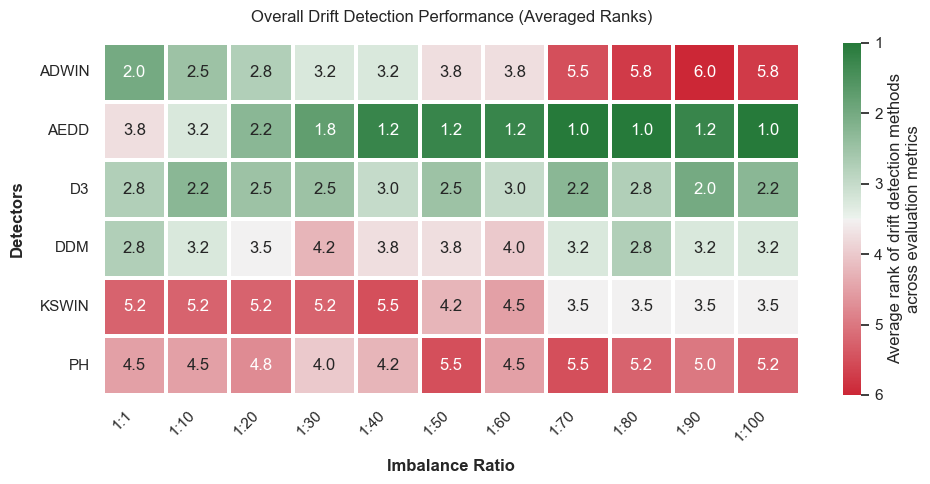

In [ ]:
df = pd.read_csv('results.csv')

def get_data(drift_speed, metric):
    """
    Load data for a specific metric and drift speed.
    Returns a DataFrame with imbalance ratios as index and detectors as columns.
    
    Parameters:
    - drift_speed: 'sudden' or 'gradual'
    - metric: 'gmean', 'mtd', 'mtfa', 'mtr', 'hdd', 'far'
    """
    
    # Filter data
    df_filtered = df[
        (df['Drift_Type'].str.lower() == drift_speed) &
        (df['Environment'] == 'Synthetic')  
    ]
    
    pivot_df = df_filtered.pivot_table(
        index='IR', 
        columns='Detector', 
        values=metric
    )
    
    return pivot_df


metrics_to_combine = ["mtd", "gmean", "mtfa", "mtr"]
ranked_dfs = []

for metric in metrics_to_combine:
    df_metric = get_data("sudden", metric)
    
    if metric in ["mtr", "gmean", "mtfa"]:
        # HIGHER is better 
        df_ranked = df_metric.rank(axis=1, ascending=False)
    else:
        # LOWER is better (mtd, far) 
        df_ranked = df_metric.rank(axis=1, ascending=True)
    
    ranked_dfs.append(df_ranked)


df_combined_ranks = pd.concat(ranked_dfs).groupby(level=0).mean()

column_order = [
    "1:1",
    "1:10",
    "1:20",
    "1:30",
    "1:40",
    "1:50",
    "1:60",
    "1:70",
    "1:80",
    "1:90",
    "1:100",
]

df_combined_ranks = df_combined_ranks.T[column_order]

plt.figure(figsize=(10, 5))
sns.set_theme(style="white")

# Green for top rank (1.0), Red for bottom rank (6.0)
cmap = sns.diverging_palette(133, 10, s=85, l=45, n=7, as_cmap=True)

ax = sns.heatmap(
    df_combined_ranks,
    annot=True,  # decimal average ranks
    fmt=".1f",  # one decimal place
    cmap=cmap,
    vmin=1,
    vmax=6,
    linewidths=1.5,
    linecolor="white",
    cbar_kws={
        "label": "Average rank of drift detection methods\nacross evaluation metrics",
        "ticks": range(1, 7),
    },
)


ax.figure.axes[-1].invert_yaxis()  # invert colorbar so 1 is at the top
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.xlabel("Imbalance Ratio", fontweight="bold", labelpad=10)
plt.ylabel("Detectors", fontweight="bold", labelpad=10)
plt.title(
    "Overall Drift Detection Performance (Averaged Ranks)", pad=15, fontsize=12
)

plt.tight_layout()
plt.show()


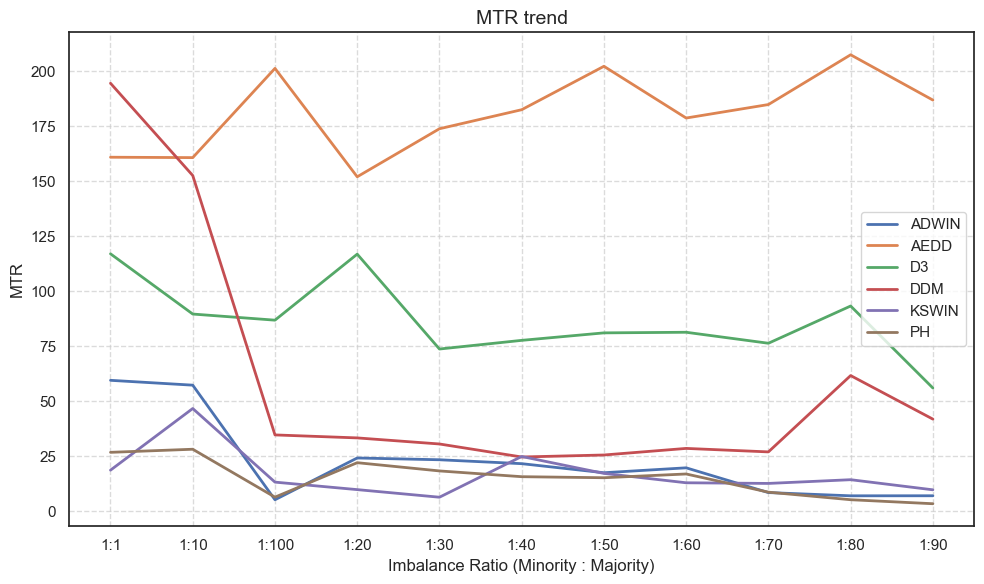

In [ ]:
def plot_trend(data, metric):
    """data: DataFrame from get_data()"""
    df = pd.DataFrame(data)  
    plt.figure(figsize=(10, 6))
    for column in df.columns:
        plt.plot(df.index, df[column], label=column, linewidth=2, markersize=8)
    plt.title(f'{metric} trend', fontsize=14)
    plt.xlabel('Imbalance Ratio (Minority : Majority)', fontsize=12)
    plt.ylabel(metric, fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
drift_speed="gradual"
metric="mtr"
mtr_data=get_data(drift_speed, metric)
plot_trend(mtr_data, metric.upper())

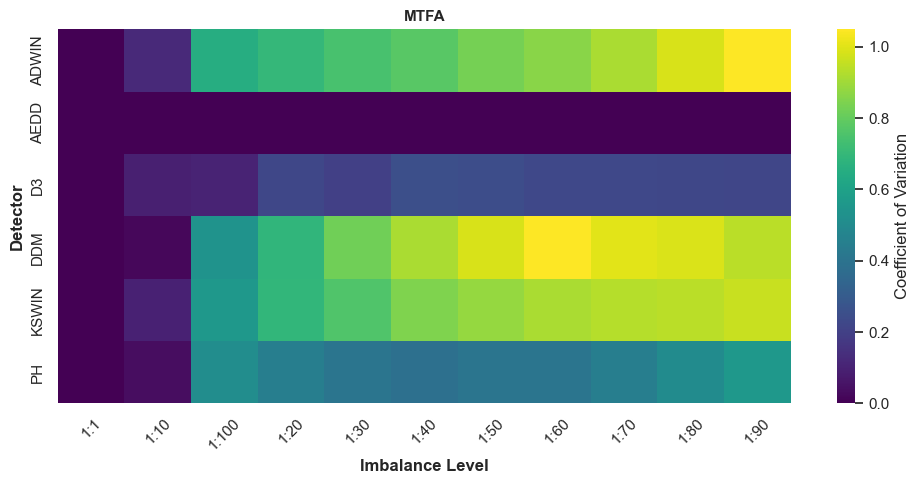

In [41]:
def plot_cv_heatmap(metric_data, title):
    """metric_data: DataFrame from get_data()"""
    detectors = metric_data.columns.tolist()
    imbalance_levels = metric_data.index.tolist()
    
    cv_values = {}
    
    for det in detectors:
        values = metric_data[det].values
        baseline = values[0]
        norm = values / baseline  # normalization
        cvs = []
        for i in range(len(norm)):
            subset = norm[:i+1]
            mean = np.mean(subset)
            if np.isclose(mean, 0):
                cvs.append(np.nan)
            else:
                cvs.append(np.std(subset) / mean)
        cv_values[det] = cvs
    df_cv = pd.DataFrame(cv_values, index=imbalance_levels).T
    
    # Plot heatmap
    plt.figure(figsize=(10, 5))
    sns.heatmap(df_cv, cmap='viridis', annot=False, fmt=".3f",
                cbar_kws={'label': 'Coefficient of Variation'})
    plt.title(title, fontsize=11, fontweight='bold')
    plt.xlabel("Imbalance Level", fontweight='bold')
    plt.ylabel("Detector", fontweight='bold')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

drift_speed="sudden"
metric='mtfa'
plot_cv_heatmap(get_data(drift_speed, metric), f"{metric.upper()}")

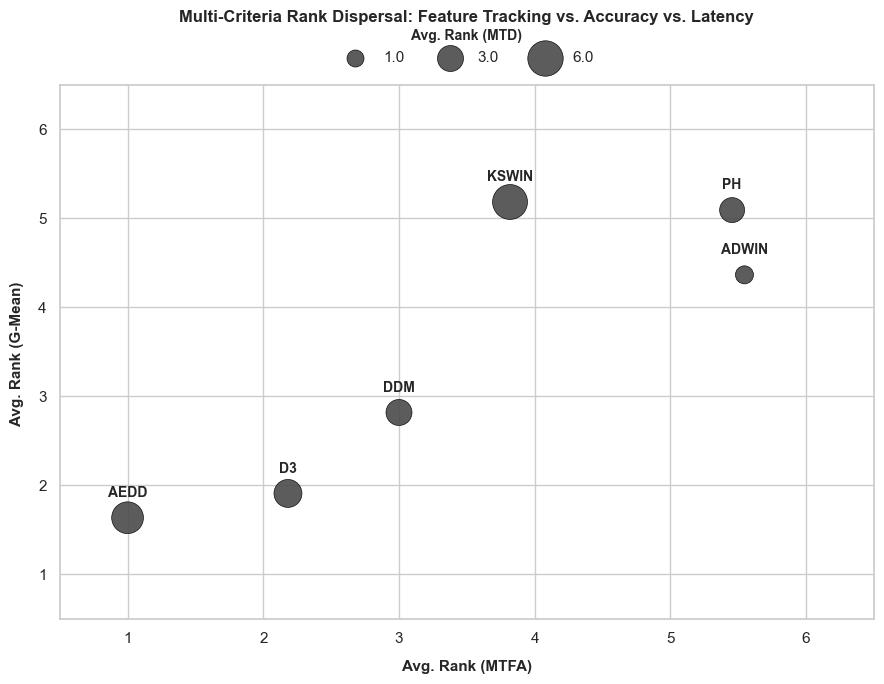

In [ ]:
gmean_raw = get_data("gradual", "gmean")  
mtfa_raw = get_data("gradual", "mtfa")
mtd_raw = get_data("gradual", "mtd")

detectors = gmean_raw.columns.tolist()  # Detectors list

df_gmean = gmean_raw[detectors]  
df_mtfa = mtfa_raw[detectors]
df_mtd = mtd_raw[detectors]


rank_gmean = df_gmean.rank(axis=1, ascending=False).mean() # G-Mean: Higher is better 
rank_mtfa = df_mtfa.rank(axis=1, ascending=False).mean() # MTFA: Higher is better
rank_mtd = df_mtd.rank(axis=1, ascending=True).mean() # MTD and Delay: Lower is better 

df_ranks = pd.DataFrame({
    'Detector': detectors,
    'Rank_MTFA': rank_mtfa.values,
    'Rank_GMean': rank_gmean.values,
    'Rank_MTD': rank_mtd.values
})


plt.figure(figsize=(9, 7))
sns.set_theme(style="whitegrid")
min_bubble_size = 50
bubble_scaling_factor = 100
sizes = min_bubble_size + (df_ranks['Rank_MTD'] * bubble_scaling_factor)
scatter = plt.scatter(
    x=df_ranks['Rank_MTFA'],
    y=df_ranks['Rank_GMean'],
    s=sizes,
    color='#4A4A4A',
    alpha=0.9,
    edgecolors='black',
    linewidths=0.5
)

for idx, row in df_ranks.iterrows():
    plt.annotate(
        row['Detector'],
        (row['Rank_MTFA'], row['Rank_GMean']),
        textcoords="offset points",
        xytext=(0, 15),  # vertical offset
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.xlim(0.5, 6.5)
plt.ylim(0.5, 6.5)

plt.xlabel("Avg. Rank (MTFA)", fontsize=11, fontweight='bold', labelpad=10)
plt.ylabel("Avg. Rank (G-Mean) ", fontsize=11, fontweight='bold', labelpad=10)
plt.title("Multi-Criteria Rank Dispersal: Feature Tracking vs. Accuracy vs. Latency", fontsize=12, fontweight='bold', pad=45)

handles, labels = [], []
for r in [1.0, 3.0, 6.0]:
    sz = min_bubble_size + (r * bubble_scaling_factor)
    handles.append(plt.scatter([], [], s=sz, color='#4A4A4A', alpha=0.9, edgecolors='black', linewidths=0.5))
    labels.append(f"{r:.1f}")

plt.legend(
    handles, labels,
    title="Avg. Rank (MTD)",
    loc='upper center',
    bbox_to_anchor=(0.5, 1.13),
    ncol=3,
    frameon=False,
    title_fontproperties={'weight': 'bold', 'size': 10}
)

plt.tight_layout()
plt.show()

### Statistical Analysis


--- MTR Statistical Analysis ---
Friedman Test p-value: 0.0000000066

Average Ranks (Lower is better):
Detector
AEDD     1.090909
D3       2.181818
DDM      2.818182
ADWIN    4.636364
KSWIN    4.818182
PH       5.454545
dtype: float64


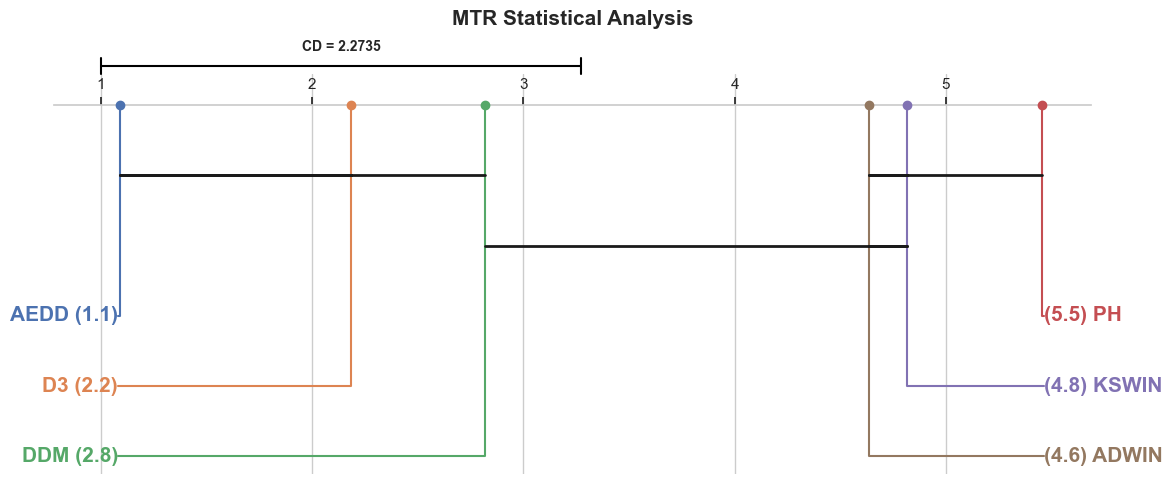

In [ ]:
def run_statistical_analysis(df, title):
    stat, p = friedmanchisquare(*[df[col] for col in df.columns])
    print(f"\n--- {title} ---")
    print(f"Friedman Test p-value: {p:.10f}")
    
    if p < 0.05:
        avg_ranks = df.rank(axis=1, ascending=False).mean()
        print("\nAverage Ranks (Lower is better):")
        print(avg_ranks.sort_values())
        
        pc = sp.posthoc_nemenyi_friedman(df.values)
        pc.columns = df.columns
        pc.index = df.columns
        
        k = len(df.columns)
        N = len(df)
        q_alpha = 2.850 
        cd_value = q_alpha * np.sqrt((k * (k + 1)) / (6 * N))

        plt.figure(figsize=(12, 5))
        ax = plt.gca()
        
        sp.critical_difference_diagram(avg_ranks, pc)

        for text in ax.texts:
            if "CD" not in text.get_text():
                text.set_fontsize(15)       
                text.set_fontweight('bold') 
        
        trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
        
        cd_start_x = 1.0 
        cd_y = 1.02       
        cap_size = 0.02   
        
        ax.plot([cd_start_x, cd_start_x + cd_value], [cd_y, cd_y], 
                color='black', lw=1.5, transform=trans, clip_on=False)
        ax.plot([cd_start_x, cd_start_x], [cd_y - cap_size, cd_y + cap_size], 
                color='black', lw=1.5, transform=trans, clip_on=False)
        ax.plot([cd_start_x + cd_value, cd_start_x + cd_value], [cd_y - cap_size, cd_y + cap_size], 
                color='black', lw=1.5, transform=trans, clip_on=False)
        
        ax.text(cd_start_x + (cd_value / 2), cd_y + 0.03, f"CD = {cd_value:.4f}", 
                ha='center', va='bottom', fontsize=10, fontweight='bold', 
                transform=trans, clip_on=False)
        
        plt.title(f"{title}", pad=35, fontsize=15, fontweight='bold')
        
        current_ylim = ax.get_ylim()
        ax.set_ylim(current_ylim[0], current_ylim[1] + 0.2)
        
        plt.tight_layout()
        plt.show()
    else:
        print("The difference is statistically insignificant.")

drift_speed = "gradual"
metric = "mtr"
df = get_data(drift_speed, metric) 
run_statistical_analysis(df, f"{metric.upper()} Statistical Analysis")